In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# ============================================================
# CELLULE 0 — INSTALLATION CHATTERBOX (Kaggle GPU T4/P100)
# Colle ce code dans une cellule AVANT ton script principal
# ============================================================
# Problème connu : pip install chatterbox-tts échoue à cause
# de pkuseg==0.0.25 qui ne compile pas sur Python 3.12
# Solution : cloner depuis GitHub + supprimer pkuseg du toml
# ============================================================

import subprocess, sys, os

def run(cmd, **kw):
    print(f"  $ {cmd}")
    result = subprocess.run(cmd, shell=True, capture_output=False, **kw)
    return result.returncode

print("=" * 55)
print("  INSTALLATION CHATTERBOX — FIX pkuseg")
print("=" * 55)

# ── Étape 1 : Outils de base ────────────────────────────────
print("\n[1/7] Mise à jour pip + setuptools...")
run("pip install -q -U pip 'setuptools<81' wheel")

# ── Étape 2 : numpy AVANT tout (requis par pkuseg) ──────────
print("\n[2/7] Préinstallation numpy>=1.26...")
run("pip install -q 'numpy>=1.26.0'")

# ── Étape 3 : PyTorch CUDA (déjà présent sur Kaggle GPU) ────
print("\n[3/7] Vérification PyTorch CUDA...")
try:
    import torch
    print(f"  torch {torch.__version__} — CUDA: {torch.cuda.is_available()}")
except ImportError:
    print("  Installation PyTorch CUDA 12.1...")
    run("pip install -q torch torchaudio --index-url https://download.pytorch.org/whl/cu121")

# ── Étape 4 : Dépendances Chatterbox (sans pkuseg) ──────────
print("\n[4/7] Installation dépendances Chatterbox...")
deps = [
    "transformers==4.46.3",
    "diffusers==0.29.0",
    "conformer==0.3.2",
    "resemble-perth==1.0.1",
    "safetensors==0.5.3",
    "librosa==0.11.0",
    "soundfile",
    "torchaudio",
    "einops",
]
run("pip install -q " + " ".join(f'"{d}"' for d in deps))

# ── Étape 5 : s3tokenizer + onnx (sans les extras) ──────────
print("\n[5/7] s3tokenizer + onnx...")
run("pip install -q 'onnx==1.16.2'")
run("pip install -q --no-deps s3tokenizer==0.2.0")

# ── Étape 6 : Cloner chatterbox et patcher pyproject.toml ───
print("\n[6/7] Clonage + patch pkuseg...")

CHATTERBOX_DIR = "/tmp/chatterbox"

if not os.path.exists(CHATTERBOX_DIR):
    run(f"git clone -q https://github.com/resemble-ai/chatterbox.git {CHATTERBOX_DIR}")
else:
    print(f"  Dossier {CHATTERBOX_DIR} déjà présent")

# Lire le pyproject.toml
toml_path = f"{CHATTERBOX_DIR}/pyproject.toml"
with open(toml_path, "r") as f:
    toml_content = f.read()

# Supprimer toutes les lignes qui mentionnent pkuseg
lines = toml_content.split("\n")
patched_lines = [l for l in lines if "pkuseg" not in l.lower()]
patched = "\n".join(patched_lines)

with open(toml_path, "w") as f:
    f.write(patched)

# Vérifier que pkuseg est bien supprimé
if "pkuseg" not in patched:
    print("  pkuseg supprimé du pyproject.toml ✓")
else:
    print("  ATTENTION : pkuseg toujours présent !")

# ── Étape 7 : Installer chatterbox depuis le clone patché ───
print("\n[7/7] Installation chatterbox (--no-deps)...")
ret = run(f"pip install -q --no-deps -e {CHATTERBOX_DIR}")

if ret == 0:
    print("\n  Vérification import...")
    try:
        import importlib, sys
        # Forcer le rechargement si déjà importé
        for mod in list(sys.modules.keys()):
            if "chatterbox" in mod:
                del sys.modules[mod]

        from chatterbox.tts import ChatterboxTTS
        print("  ✅ ChatterboxTTS importé avec succès")
        try:
            from chatterbox.mtl_tts import ChatterboxMultilingualTTS
            print("  ✅ ChatterboxMultilingualTTS importé avec succès")
        except ImportError:
            print("  ⚠️  ChatterboxMultilingualTTS absent — le modèle EN sera utilisé")
    except ImportError as e:
        print(f"  ❌ Import échoué : {e}")
        print("  → Essaie de redémarrer le kernel Kaggle et relance cette cellule")
else:
    print(f"\n  ❌ Installation échouée (code {ret})")

# ── espeak-ng ────────────────────────────────────────────────
print("\n[+] espeak-ng...")
run("apt-get install -q -y espeak-ng libespeak-ng-dev")
result = subprocess.run(["espeak-ng", "--version"],
                        capture_output=True, text=True)
if result.returncode == 0:
    print(f"  ✅ {result.stdout.strip()}")
else:
    print("  ❌ espeak-ng non trouvé")

print("\n" + "=" * 55)
print("  INSTALLATION TERMINÉE")
print("  Redémarre le kernel si l'import échoue encore")
print("=" * 55)

  INSTALLATION CHATTERBOX — FIX pkuseg

[1/7] Mise à jour pip + setuptools...
  $ pip install -q -U pip 'setuptools<81' wheel

[2/7] Préinstallation numpy>=1.26...
  $ pip install -q 'numpy>=1.26.0'

[3/7] Vérification PyTorch CUDA...
  torch 2.10.0+cu128 — CUDA: True

[4/7] Installation dépendances Chatterbox...
  $ pip install -q "transformers==4.46.3" "diffusers==0.29.0" "conformer==0.3.2" "resemble-perth==1.0.1" "safetensors==0.5.3" "librosa==0.11.0" "soundfile" "torchaudio" "einops"

[5/7] s3tokenizer + onnx...
  $ pip install -q 'onnx==1.16.2'
  $ pip install -q --no-deps s3tokenizer==0.2.0

[6/7] Clonage + patch pkuseg...
  Dossier /tmp/chatterbox déjà présent
  pkuseg supprimé du pyproject.toml ✓

[7/7] Installation chatterbox (--no-deps)...
  $ pip install -q --no-deps -e /tmp/chatterbox

  Vérification import...


/usr/local/lib/python3.12/dist-packages/perth/perth_net/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
2026-03-25 08:44:12.725065: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774428252.961238     260 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774428253.022070     260 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774428253.572633     260 computation_placer.cc:177] computation p

  ✅ ChatterboxTTS importé avec succès
  ✅ ChatterboxMultilingualTTS importé avec succès

[+] espeak-ng...
  $ apt-get install -q -y espeak-ng libespeak-ng-dev
Reading package lists...
Building dependency tree...
Reading state information...
libespeak-ng-dev is already the newest version (1.50+dfsg-10ubuntu0.1).
espeak-ng is already the newest version (1.50+dfsg-10ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 133 not upgraded.
  ✅ eSpeak NG text-to-speech: 1.50  Data at: /usr/lib/x86_64-linux-gnu/espeak-ng-data

  INSTALLATION TERMINÉE
  Redémarre le kernel si l'import échoue encore


In [3]:
"""
=============================================================================
DATASET GENERATOR — 600 AUDIO FRANÇAIS (CLEAN + NOISY)
Moteur : Chatterbox Multilingual (ResembleAI) — MIT License
=============================================================================
  300 CLEAN : 150 voix féminines + 150 voix masculines
  300 NOISY : même texte + bruit synthétique mixé
  CSV master  : 600 lignes (chemin, texte, IPA, genre, SNR, bruit...)
  CSV phonèmes : fréquences par symbole IPA
=============================================================================
INSTALLATION (cellule Kaggle à lancer d'abord) :
  !pip install -q chatterbox-tts torchaudio soundfile
  !apt-get install -q -y espeak-ng libespeak-ng-dev
=============================================================================
"""
!apt-get install -q -y espeak-ng libespeak-ng-dev


# =============================================================================
# SECTION 1 — IMPORTS
# =============================================================================
import os, re, csv, wave, json, time, random, subprocess
import collections, shutil
from pathlib import Path
import numpy as np
import torch
import torchaudio as ta
import soundfile as sf

# =============================================================================
# SECTION 2 — CONFIGURATION
# =============================================================================
N_PHRASES       = 300
SAMPLE_RATE     = 24000        # Hz natif Chatterbox
SNR_LEVELS_DB   = [0, 5, 10, 15]
NOISE_TYPES     = ["white", "pink", "babble", "traffic"]
RETRY_MAX       = 3
RETRY_DELAY     = 3

# Paramètres Chatterbox (https://github.com/resemble-ai/chatterbox)
# exaggeration : 0.25–2.0  (0.5 = neutre, >0.7 = expressif)
# cfg_weight   : 0.2–1.0   (0.5 = normal, 0.3 = débit plus lent)
# temperature  : 0.05–5.0  (0.7 = bonne balance stabilité/variété)
CHATTERBOX_PARAMS_FEMALE = dict(exaggeration=0.45, cfg_weight=0.5, temperature=0.7)
CHATTERBOX_PARAMS_MALE   = dict(exaggeration=0.55, cfg_weight=0.4, temperature=0.8)

# Dossiers
BASE_DIR        = Path("/kaggle/working/dataset_chatterbox")
AUDIO_CLEAN_DIR = BASE_DIR / "audio" / "clean"
AUDIO_NOISY_DIR = BASE_DIR / "audio" / "noisy"
REF_AUDIO_DIR   = BASE_DIR / "ref_audio"
CSV_MASTER      = BASE_DIR / "dataset_master.csv"
CSV_PHONEMES    = BASE_DIR / "phonemes_stats.csv"
CHECKPOINT_FILE = BASE_DIR / "checkpoint.json"

# =============================================================================
# SECTION 3 — CRÉATION AUTOMATIQUE DES AUDIO DE RÉFÉRENCE H/F
# =============================================================================
# Chatterbox clone la voix depuis un fichier WAV de référence (6–30s)
# Si tu n'as pas de fichier de référence, le script en génère
# des synthétiques simples (sinusoïdes + bruit rose) qui donnent
# des voix neutres. Pour une meilleure qualité : fournir des vrais WAV.
#
# Pour fournir tes propres références :
#   REF_FEMALE = "/chemin/vers/voix_femme.wav"   # 10–30s de parole claire
#   REF_MALE   = "/chemin/vers/voix_homme.wav"   # 10–30s de parole claire
#
REF_FEMALE = str(REF_AUDIO_DIR / "ref_female.wav")
REF_MALE   = str(REF_AUDIO_DIR / "ref_male.wav")

# =============================================================================
# SECTION 4 — 300 PHRASES FRANÇAISES DIVERSIFIÉES
# =============================================================================
PHRASES_FR = [
    # Sciences & technologie
    "Les réseaux de neurones convolutifs permettent d'analyser des images avec une précision remarquable.",
    "L'apprentissage par renforcement est utilisé pour entraîner des agents à jouer aux échecs.",
    "La transformée de Fourier décompose un signal en ses composantes fréquentielles fondamentales.",
    "Les algorithmes de tri comme quicksort offrent une complexité moyenne de O(n log n).",
    "Les transistors à effet de champ sont les composants de base des circuits intégrés modernes.",
    "La cryptographie asymétrique repose sur des problèmes mathématiques difficiles à inverser.",
    "Les modèles de langage de grande taille génèrent du texte en prédisant le prochain token.",
    "L'optique quantique étudie l'interaction entre la lumière et la matière au niveau des photons.",
    "Les supraconducteurs perdent toute résistance électrique en dessous d'une température critique.",
    "La mécanique des fluides décrit le comportement des liquides et des gaz en mouvement.",
    "Les fibres optiques transmettent des données à la vitesse de la lumière sur de longues distances.",
    "La robotique collaborative permet aux machines de travailler aux côtés des humains en toute sécurité.",
    "Les batteries à ions lithium stockent l'énergie grâce à des réactions électrochimiques réversibles.",
    "L'impression tridimensionnelle révolutionne la fabrication en permettant la création d'objets complexes.",
    "Les capteurs LIDAR mesurent les distances en émettant des impulsions laser et en analysant leur retour.",
    "La réalité augmentée superpose des informations numériques sur l'environnement physique réel.",
    "Les systèmes de reconnaissance vocale convertissent la parole en texte en temps réel.",
    "L'informatique quantique exploite les propriétés de superposition et d'intrication des qubits.",
    "Les réseaux maillés permettent à chaque nœud de transmettre des données pour les autres nœuds.",
    "La vision par ordinateur permet aux machines d'interpréter et de comprendre le contenu visuel.",

    # Médecine & biologie
    "Les anticorps monoclonaux sont utilisés comme traitements ciblés dans de nombreux types de cancers.",
    "Le séquençage génomique permet d'identifier des mutations responsables de maladies héréditaires.",
    "Les cellules souches ont la capacité unique de se différencier en différents types cellulaires.",
    "L'imagerie par résonance magnétique fournit des images détaillées des structures internes du corps.",
    "Les vaccins à ARN messager représentent une avancée majeure dans la lutte contre les infections virales.",
    "La médecine personnalisée adapte les traitements aux caractéristiques génétiques de chaque patient.",
    "Les bactéries du microbiome intestinal jouent un rôle crucial dans la digestion et l'immunité.",
    "Les antibiotiques perturbent la synthèse de la paroi cellulaire des bactéries pathogènes.",
    "Le système lymphatique transporte la lymphe et joue un rôle essentiel dans la défense immunitaire.",
    "Les neurotransmetteurs comme la sérotonine régulent l'humeur, le sommeil et l'appétit.",
    "La chirurgie laparoscopique utilise de petites incisions et une caméra pour opérer avec précision.",
    "Les maladies auto-immunes surviennent quand le système immunitaire attaque les tissus sains.",
    "La thérapie génique vise à corriger des anomalies génétiques en introduisant des gènes sains.",
    "Le cortex préfrontal est impliqué dans la prise de décision, la planification et le contrôle des impulsions.",
    "Les mitochondries produisent l'ATP, la principale source d'énergie des cellules eucaryotes.",
    "La pharmacocinétique étudie comment l'organisme absorbe, distribue et élimine les médicaments.",
    "Les prostaglandines sont des médiateurs chimiques qui participent à la réponse inflammatoire.",
    "La technique CRISPR-Cas9 permet d'éditer le génome avec une précision sans précédent.",
    "L'ostéoporose fragilise les os en réduisant leur densité minérale, augmentant le risque de fractures.",
    "Les lymphocytes T cytotoxiques éliminent les cellules infectées par des virus ou cancéreuses.",

    # Environnement & nature
    "Le réchauffement climatique entraîne une élévation du niveau des mers menaçant les zones côtières.",
    "La photosynthèse permet aux plantes de convertir l'énergie lumineuse en glucides grâce à la chlorophylle.",
    "Les zones humides jouent un rôle fondamental dans la filtration de l'eau et la protection contre les inondations.",
    "La biodiversité des forêts tropicales abrite environ la moitié des espèces vivantes connues sur Terre.",
    "Les pollinisateurs comme les abeilles sont essentiels à la reproduction de nombreuses plantes cultivées.",
    "L'acidification des océans menace les coraux et de nombreux organismes marins à coquilles calcaires.",
    "Les énergies renouvelables comme le solaire et l'éolien réduisent la dépendance aux combustibles fossiles.",
    "La déforestation amazonienne accélère la libération de dioxyde de carbone stocké dans les sols.",
    "Les glaciers arctiques fondent à un rythme alarmant, perturbant les courants océaniques mondiaux.",
    "La permaculture est une approche agricole qui imite les écosystèmes naturels pour une production durable.",
    "Les espèces invasives déséquilibrent les écosystèmes en concurrençant les espèces locales pour les ressources.",
    "La migration des oiseaux représente l'un des phénomènes naturels les plus spectaculaires et réguliers.",
    "Les mangroves protègent les côtes contre l'érosion et servent de nurseries pour de nombreux poissons.",
    "Le cycle de l'azote implique des bactéries qui transforment l'azote atmosphérique en formes utilisables.",
    "Les volcans sous-marins libèrent des minéraux qui nourrissent des écosystèmes profonds uniques.",
    "Les séismes résultent du déplacement brutal des plaques tectoniques le long des failles géologiques.",
    "L'ozone stratosphérique protège la Terre des rayonnements ultraviolets dangereux émis par le Soleil.",
    "Les marées noires causent des dommages irréversibles aux écosystèmes côtiers et à la faune marine.",
    "La symbiose mycorhizienne permet aux champignons et aux racines des plantes de s'échanger nutriments.",
    "Le cycle de l'eau régule les températures planétaires et distribue l'humidité sur toute la surface.",

    # Quotidien & culture
    "La cuisine française est reconnue comme patrimoine culturel immatériel de l'humanité par l'UNESCO.",
    "Le train à grande vitesse relie Paris à Lyon en moins de deux heures, transformant les habitudes de voyage.",
    "Les marchés de Noël alsaciens attirent chaque année des millions de visiteurs du monde entier.",
    "La Bibliothèque nationale de France conserve des millions de documents, manuscrits et ouvrages rares.",
    "Le baccalauréat français, créé par Napoléon Bonaparte, reste un rite de passage pour les lycéens.",
    "La gastronomie lyonnaise, avec ses bouchons et ses spécialités régionales, est reconnue mondialement.",
    "L'architecture haussmannienne a profondément redessiné le visage de Paris au dix-neuvième siècle.",
    "Le Tour de France cycliste traverse chaque été des régions pittoresques aux paysages extraordinaires.",
    "Les fromages français se comptent par centaines, chacun reflétant le terroir et le savoir-faire local.",
    "Le système de santé français est régulièrement classé parmi les meilleurs au monde selon l'OMS.",
    "Les jardins à la française, comme ceux de Versailles, illustrent une maîtrise absolue de la géométrie.",
    "La mode parisienne influence les tendances vestimentaires mondiales depuis plusieurs siècles.",
    "Le Louvre est le musée le plus visité au monde avec plus de dix millions de visiteurs annuels.",
    "Les vins de Bordeaux sont classés selon un système mis en place lors de l'Exposition universelle.",
    "La Seine traverse Paris d'est en ouest sur trente kilomètres, ponctuée de trente-sept ponts.",

    # Histoire & arts
    "Le mouvement impressionniste, né en France au dix-neuvième siècle, a révolutionné la peinture mondiale.",
    "Victor Hugo, auteur des Misérables, était également un ardent défenseur de la République.",
    "La cathédrale Notre-Dame de Paris, chef-d'œuvre gothique, a subi un incendie dévastateur en 2019.",
    "Marcel Proust a passé quinze ans à écrire À la recherche du temps perdu, une fresque monumentale.",
    "La Révolution française de mille sept cent quatre-vingt-neuf a proclamé les droits de l'homme.",
    "Le cinéma de la Nouvelle Vague a bouleversé l'industrie filmique mondiale à partir des années soixante.",
    "Claude Monet a peint sa série des Nymphéas dans son jardin de Giverny à la fin de sa vie.",
    "La philosophie des Lumières a posé les fondements intellectuels de la démocratie moderne en Europe.",
    "Gustave Eiffel a construit sa tour en fer pour l'Exposition universelle de mille huit cent quatre-vingt-neuf.",
    "Simone de Beauvoir a posé les bases du féminisme philosophique dans Le Deuxième Sexe.",
    "Jules Verne a imaginé des technologies comme le sous-marin et le voyage spatial bien avant leur réalisation.",
    "Blaise Pascal a inventé la pascaline, l'une des premières machines à calculer mécaniques.",
    "Le philosophe René Descartes a posé les bases du rationalisme avec son cogito ergo sum.",
    "Jean-Baptiste Lully a introduit la tragédie en musique à la cour de Versailles au dix-septième siècle.",
    "Les grottes de Lascaux abritent des peintures rupestres vieilles de dix-sept mille ans.",

    # Phonèmes difficiles (glides, nasales, liaisons, schwa)
    "Hier au soir, les yeux brillants d'émotion, elle leur a dit au revoir avec une joie sincère.",
    "Les vieilles pierreries de la bijouterie illuminaient les vitrines du magasin.",
    "Bien qu'il ait peu voyagé, il connaissait admirablement la géographie mondiale.",
    "Les nuances subtiles entre les voyelles nasales françaises déconcertent souvent les apprenants.",
    "Un pied-à-terre parisien reste le rêve inaccessible de nombreux provinciaux.",
    "La jonquille et la feuille de lierre ornaient les pierres du vieux puits du jardin.",
    "Elle siffle, yodelle et joue de la trompette avec une aisance déconcertante.",
    "Le yaourt aux fruits rouges que tu apprécies est fabriqué dans la Drôme.",
    "Yannick enviait la dextérité de son ami luthier qui sculptait les violons.",
    "La grenouille sautait d'un nénuphar à l'autre dans la douceur du soir estival.",
    "Je vous envoie par avion ce colis contenant des noix et des yaourts artisanaux.",
    "Les pneus de la voiture criaient dans les virages serrés de la route de montagne.",
    "La faille tectonique traverse la région en diagonale sur plusieurs centaines de kilomètres.",
    "Les fouilles archéologiques ont mis au jour des vestiges d'une ville gallo-romaine.",
    "Le meunier moulait le blé tandis que les mouettes criaient au-dessus du moulin.",

    # Phrases courtes naturelles
    "Il fait beau aujourd'hui.",
    "Le chien aboie dans le jardin.",
    "Tu viens dîner ce soir ?",
    "Passe-moi le sel, s'il te plaît.",
    "La réunion est annulée demain.",
    "J'ai oublié mon parapluie chez toi.",
    "Ce film est extraordinaire.",
    "Où est la gare la plus proche ?",
    "Il pleut depuis ce matin.",
    "Nous avons rendez-vous à midi.",
    "Ce vin est excellent.",
    "La route est glissante ce soir.",
    "J'aime beaucoup cette chanson.",
    "Le bébé dort enfin.",
    "Ferme la fenêtre, il fait froid.",
    "Nous partons en vacances vendredi.",
    "Est-ce que tu as du pain ?",
    "Le bus est encore en retard.",
    "Elle a réussi son examen.",
    "Appelle-moi quand tu arrives.",

    # Phrases longues et complexes
    "Malgré les nombreuses difficultés rencontrées lors de l'expédition, les scientifiques ont réussi à collecter des échantillons exceptionnels.",
    "La complexité des interactions entre les espèces au sein des écosystèmes marins dépasse encore notre capacité de modélisation.",
    "Les nouvelles réglementations européennes sur la protection des données personnelles ont profondément transformé les pratiques numériques.",
    "Le développement durable requiert une coordination internationale sans précédent entre gouvernements, entreprises et organisations civiles.",
    "La philosophie de l'éducation interroge les finalités du système scolaire et son rôle dans la formation des citoyens.",
    "Les avancées récentes en intelligence artificielle soulèvent des questions fondamentales sur l'avenir du travail et de la créativité.",
    "Depuis la révolution industrielle, les émissions de gaz à effet de serre ont augmenté de façon exponentielle.",
    "L'architecture bioclimatique intègre les conditions environnementales locales pour minimiser la consommation énergétique des bâtiments.",
    "La linguistique computationnelle combine des méthodes statistiques et des règles grammaticales pour analyser le langage naturel.",
    "Les politiques de redistribution fiscale visent à réduire les inégalités sociales sans décourager l'initiative économique.",

    # Discours scientifique
    "Les résultats préliminaires suggèrent une corrélation significative entre les variables indépendantes testées.",
    "Cette hypothèse nécessite une validation expérimentale rigoureuse avant toute généralisation.",
    "Les données recueillies lors de l'enquête ont été analysées à l'aide d'un modèle de régression logistique.",
    "La reproductibilité des expériences est un critère fondamental de la démarche scientifique moderne.",
    "Les biais cognitifs influencent systématiquement nos jugements et nos prises de décision quotidiennes.",
    "L'interopérabilité des systèmes d'information reste un défi majeur dans l'administration publique.",
    "La standardisation des protocoles médicaux améliore la qualité et la sécurité des soins dispensés.",
    "Les indicateurs macroéconomiques permettent d'évaluer la santé globale d'une économie nationale.",
    "La modélisation climatique intègre des milliers de variables pour simuler l'évolution du système terrestre.",
    "L'anthropologie culturelle étudie les sociétés humaines dans leur diversité historique et géographique.",

    # Économie
    "La Banque centrale européenne régule la politique monétaire de la zone euro depuis sa création.",
    "Le produit intérieur brut mesure la valeur totale des biens et services produits dans un pays.",
    "Les marchés financiers réagissent souvent de manière excessive aux annonces économiques des banques centrales.",
    "La globalisation a profondément transformé les chaînes d'approvisionnement et les modèles de production.",
    "Le revenu universel de base fait l'objet d'expérimentations dans plusieurs pays européens.",
    "Les inégalités de revenus se creusent dans la plupart des économies développées depuis les années quatre-vingt.",
    "La transition écologique nécessite des investissements massifs dans les infrastructures énergétiques.",
    "Les cryptomonnaies décentralisées remettent en question le monopole des États sur les émissions monétaires.",
    "Le traité de Maastricht a posé les fondations de l'Union économique et monétaire européenne.",
    "La dette publique française dépasse cent dix pour cent du produit intérieur brut depuis la crise.",

    # Phrases additionnelles variées
    "Le château de Chambord, avec ses cent quarante mètres de façade, est le plus grand château de la Loire.",
    "La pétanque, originaire de Provence, est pratiquée dans tout le pays comme loisir populaire.",
    "Les vendanges bourguignonnes mobilisent des milliers de saisonniers chaque automne pour la récolte.",
    "La cathédrale de Strasbourg, construite en grès rose, domine le quartier historique de la ville.",
    "Le château de Chenonceau enjambe le Cher grâce à ses cinq arches construites au seizième siècle.",
    "Les châteaux cathares du Languedoc témoignent de la résistance des Albigeois au treizième siècle.",
    "Alexis de Tocqueville a analysé la démocratie américaine avec une lucidité remarquable pour son époque.",
    "Le théorème de Pythagore permet de calculer la longueur de l'hypoténuse d'un triangle rectangle.",
    "Molière a satirisé l'hypocrisie religieuse et sociale dans Tartuffe avec un humour dévastateur.",
    "La sécurité sociale française garantit une couverture maladie universelle pour tous les résidents.",
    "Aujourd'hui, je vous présente un extrait de la nouvelle œuvre de notre philharmonie.",
    "Les ingénieurs ont conçu un réseau ferroviaire qui relie toutes les grandes agglomérations.",
    "La maîtresse de maison avait cuisiné un gratin de courgettes à l'emmental fondu.",
    "Rien ne vaut un bon feu de cheminée pour passer une soirée d'hiver confortablement.",
    "Bien qu'il fuie les mondanités, il appréciait les réunions familiales chaleureuses.",
]

# Compléter jusqu'à N_PHRASES
random.seed(42)
while len(PHRASES_FR) < N_PHRASES:
    base = random.choice(PHRASES_FR[:100])
    PHRASES_FR.append(base + " " + random.choice([
        "C'est remarquable.", "En effet.", "Bien sûr.", "Indéniablement.", "C'est fascinant."
    ]))
PHRASES_FR = PHRASES_FR[:N_PHRASES]

# =============================================================================
# SECTION 5 — SETUP : DOSSIERS + ESPEAK + CHATTERBOX
# =============================================================================
for d in [AUDIO_CLEAN_DIR, AUDIO_NOISY_DIR, REF_AUDIO_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print(f"Dossiers créés : {BASE_DIR}")

# ── Vérifier / installer espeak-ng ──────────────────────────────────────────
def _ensure_espeak():
    import subprocess as _sub
    for p in ["/usr/bin/espeak-ng", "/usr/local/bin/espeak-ng", "espeak-ng"]:
        try:
            _sub.run([p, "--version"], capture_output=True, check=True, timeout=5)
            return p
        except Exception:
            continue
    print("Installation espeak-ng...")
    _sub.run(["apt-get", "install", "-q", "-y", "espeak-ng", "libespeak-ng-dev"],
             capture_output=True, timeout=120)
    return "/usr/bin/espeak-ng"

ESPEAK_BIN = _ensure_espeak()
print(f"espeak-ng : {ESPEAK_BIN}")

# ── Charger Chatterbox Multilingual ─────────────────────────────────────────
print("\nChargement du modèle Chatterbox Multilingual...")
try:
    from chatterbox.tts import ChatterboxTTS
    from chatterbox.mtl_tts import ChatterboxMultilingualTTS

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"  Device : {DEVICE}")

    model = ChatterboxMultilingualTTS.from_pretrained(device=DEVICE)
    print(f"  Modèle chargé (sr={model.sr} Hz)")
    USE_MULTILINGUAL = True
except ImportError as e:
    print(f"ChatterboxMultilingualTTS non disponible ({e})")
    print("Tentative avec ChatterboxTTS (English) + language_id fallback...")
    from chatterbox.tts import ChatterboxTTS
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    model = ChatterboxTTS.from_pretrained(device=DEVICE)
    USE_MULTILINGUAL = False
    print(f"  Modèle EN chargé (sr={model.sr} Hz)")

# =============================================================================
# SECTION 6 — CRÉATION DES AUDIO DE RÉFÉRENCE SYNTHÉTIQUES H/F
# =============================================================================
def _make_synthetic_ref(path: str, freq_hz: float, duration: float = 8.0):
    """
    Crée un WAV de référence synthétique si aucun fichier réel n'est fourni.
    freq_hz : ~200 Hz pour femme, ~120 Hz pour homme
    Pour une vraie qualité : remplacer par un vrai enregistrement WAV.
    """
    if Path(path).exists():
        return
    sr = 24000
    t = np.linspace(0, duration, int(sr * duration))
    # Voix synthétique : fondamentale + harmoniques + bruit rose léger
    signal = (
        0.5 * np.sin(2 * np.pi * freq_hz * t)
        + 0.2 * np.sin(2 * np.pi * freq_hz * 2 * t)
        + 0.1 * np.sin(2 * np.pi * freq_hz * 3 * t)
        + 0.05 * np.random.randn(len(t))
    )
    signal = signal / np.max(np.abs(signal)) * 0.7
    signal_int = (signal * 32767).astype(np.int16)
    with wave.open(path, "wb") as wf:
        wf.setnchannels(1); wf.setsampwidth(2); wf.setframerate(sr)
        wf.writeframes(signal_int.tobytes())
    print(f"  Référence synthétique créée : {Path(path).name} ({freq_hz}Hz)")

# Créer les références si absentes
_make_synthetic_ref(REF_FEMALE, freq_hz=200)   # voix féminine (~200 Hz)
_make_synthetic_ref(REF_MALE,   freq_hz=120)   # voix masculine (~120 Hz)

# =============================================================================
# SECTION 7 — TRANSCRIPTION IPA
# =============================================================================
def text_to_ipa(text: str) -> str:
    if not ESPEAK_BIN:
        return text.lower()
    for attempt in range(3):
        try:
            result = subprocess.run(
                [ESPEAK_BIN, "--ipa", "-l", "fr", "-q", "--"],
                input=text, capture_output=True, text=True, timeout=15,
                env={**os.environ, "LANG": "fr_FR.UTF-8"}
            )
            ipa = re.sub(r'\s+', ' ', result.stdout.strip()).replace("_", " ").strip()
            return ipa
        except FileNotFoundError:
            os.environ["PATH"] += ":/usr/bin:/usr/local/bin"
            continue
        except Exception as e:
            if attempt == 2: print(f"  IPA erreur : {e}")
            time.sleep(1)
    return ""

def extract_phonemes(ipa_str: str) -> list:
    MULTI = ['ɑ̃', 'ɔ̃', 'ɛ̃', 'œ̃', 'aɪ', 'eɪ', 'tʃ', 'dʒ']
    phones, i = [], 0
    while i < len(ipa_str):
        if ipa_str[i] in (' ', '_', '\n', '\t'):
            i += 1; continue
        matched = False
        for m in MULTI:
            if ipa_str[i:i+len(m)] == m:
                phones.append(m); i += len(m); matched = True; break
        if not matched:
            if ipa_str[i] not in ("'", 'ˈ', 'ˌ', '.', ','):
                phones.append(ipa_str[i])
            i += 1
    return [p for p in phones if p.strip()]

# =============================================================================
# SECTION 8 — GÉNÉRATION DE BRUIT
# =============================================================================
def _pink_noise(n):
    b = [0.049922035, -0.095993537, 0.050612699, -0.004408786]
    a = [1, -2.494956002, 2.017265875, -0.522189400]
    from scipy import signal as sig
    return sig.lfilter(b, a, np.random.randn(n)).astype(np.float32)

def get_noise(noise_type: str, n: int) -> np.ndarray:
    if noise_type == "white":
        return np.random.randn(n).astype(np.float32)
    elif noise_type == "pink":
        try: return _pink_noise(n)
        except: return np.random.randn(n).astype(np.float32)
    elif noise_type == "babble":
        babble = np.zeros(n, np.float32)
        for _ in range(8):
            t = np.linspace(0, n / SAMPLE_RATE, n)
            v = (np.sin(2*np.pi*random.uniform(100,300)*t)*0.4
               + np.sin(2*np.pi*random.uniform(500,1500)*t)*0.3
               + np.random.randn(n)*0.1).astype(np.float32)
            babble += v
        return babble / 4
    elif noise_type == "traffic":
        try:
            pink = _pink_noise(n)
        except:
            pink = np.random.randn(n).astype(np.float32)
        t = np.arange(n) / SAMPLE_RATE
        mod = 0.7 + 0.3 * np.sin(2*np.pi*1.0*t)
        return (pink * mod).astype(np.float32)
    return np.random.randn(n).astype(np.float32)

def mix_snr(speech: np.ndarray, noise: np.ndarray, snr_db: float) -> np.ndarray:
    noise = np.tile(noise, int(np.ceil(len(speech)/len(noise))))[:len(speech)]
    sp = np.mean(speech**2)
    if sp == 0: return speech
    np_tgt = sp / (10**(snr_db/10))
    nr = np.mean(noise**2)
    if nr == 0: return speech
    mixed = speech + noise * np.sqrt(np_tgt/nr)
    peak = np.max(np.abs(mixed))
    if peak > 0.99: mixed = mixed / peak * 0.95
    return mixed.astype(np.float32)

def tensor_to_wav(wav_tensor, path: Path, sr: int):
    if wav_tensor.dim() == 1:
        wav_tensor = wav_tensor.unsqueeze(0)
    ta.save(str(path), wav_tensor.cpu(), sr)

def wav_to_numpy(path: Path):
    with wave.open(str(path), "rb") as wf:
        sr = wf.getframerate()
        raw = wf.readframes(wf.getnframes())
    arr = np.frombuffer(raw, np.int16).astype(np.float32) / 32767
    return arr, sr

def numpy_to_wav(arr: np.ndarray, path: Path, sr: int):
    clip = np.clip(arr * 32767, -32768, 32767).astype(np.int16)
    with wave.open(str(path), "wb") as wf:
        wf.setnchannels(1); wf.setsampwidth(2); wf.setframerate(sr)
        wf.writeframes(clip.tobytes())

# =============================================================================
# SECTION 9 — GÉNÉRATION TTS CHATTERBOX
# =============================================================================
def generate_chatterbox(text: str, gender: str, output_path: Path) -> bool:
    """
    Génère un fichier WAV avec Chatterbox Multilingual (français).
    - gender : 'female' ou 'male' → choisit le fichier de référence
    - language_id="fr" → accent français natif
    """
    ref_wav = REF_FEMALE if gender == "female" else REF_MALE
    params  = CHATTERBOX_PARAMS_FEMALE if gender == "female" else CHATTERBOX_PARAMS_MALE

    for attempt in range(RETRY_MAX):
        try:
            if USE_MULTILINGUAL:
                wav = model.generate(
                    text,
                    audio_prompt_path=ref_wav,
                    language_id="fr",
                    **params
                )
            else:
                wav = model.generate(
                    text,
                    audio_prompt_path=ref_wav,
                    **params
                )

            tensor_to_wav(wav, output_path, model.sr)
            return True

        except Exception as e:
            err = str(e)
            print(f"    Tentative {attempt+1}/{RETRY_MAX} : {err[:100]}")
            if attempt < RETRY_MAX - 1:
                time.sleep(RETRY_DELAY)

    return False

# =============================================================================
# SECTION 10 — CHECKPOINT
# =============================================================================
def load_checkpoint():
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE) as f: return set(json.load(f).get("done", []))
    return set()

def save_checkpoint(done: set):
    with open(CHECKPOINT_FILE, "w") as f: json.dump({"done": list(done)}, f)

# =============================================================================
# SECTION 11 — PLAN DE GÉNÉRATION
# =============================================================================
print("\n" + "="*60)
print("  DATASET CHATTERBOX — 600 AUDIO FRANÇAIS")
print("="*60)

# Note sur la qualité des voix de référence
print("\n⚠️  CONSEIL QUALITÉ VOIX :")
print("  Le script utilise des références synthétiques par défaut.")
print("  Pour une meilleure qualité, remplace les fichiers suivants")
print("  par de vrais enregistrements WAV (10–30s de parole claire) :")
print(f"  Femme : {REF_FEMALE}")
print(f"  Homme : {REF_MALE}")
print("  (Télécharge des samples de Common Voice FR par exemple)")

# Pré-calcul IPA
print("\n[1/4] Transcription IPA (espeak-ng)...")
ipa_cache = {}
for text in PHRASES_FR:
    if text not in ipa_cache:
        ipa_cache[text] = text_to_ipa(text)
print(f"  {len(ipa_cache)} phrases transcrites.")

# Plan : (uid, idx, text, gender, split, snr, noise_type, audio_path)
plan = []
for idx, text in enumerate(PHRASES_FR):
    gender = "female" if idx % 2 == 0 else "male"
    snr    = random.choice(SNR_LEVELS_DB)
    ntype  = random.choice(NOISE_TYPES)
    plan.append({
        "uid":        f"{gender[0].upper()}{idx:04d}_clean",
        "idx": idx,   "text": text, "gender": gender,
        "split":      "clean", "snr_db": None, "noise_type": None,
        "audio_path": str(AUDIO_CLEAN_DIR / f"{gender[0].upper()}{idx:04d}_clean.wav"),
    })
    plan.append({
        "uid":        f"{gender[0].upper()}{idx:04d}_noisy",
        "idx": idx,   "text": text, "gender": gender,
        "split":      "noisy", "snr_db": snr, "noise_type": ntype,
        "audio_path": str(AUDIO_NOISY_DIR / f"{gender[0].upper()}{idx:04d}_noisy.wav"),
    })

print(f"\nPlan : {len(plan)} fichiers")
print(f"  Clean femme  : {sum(1 for x in plan if x['split']=='clean' and x['gender']=='female')}")
print(f"  Clean homme  : {sum(1 for x in plan if x['split']=='clean' and x['gender']=='male')}")
print(f"  Noisy femme  : {sum(1 for x in plan if x['split']=='noisy' and x['gender']=='female')}")
print(f"  Noisy homme  : {sum(1 for x in plan if x['split']=='noisy' and x['gender']=='male')}")

# =============================================================================
# SECTION 12 — GÉNÉRATION PRINCIPALE
# =============================================================================
done_uids = load_checkpoint()
results   = []
errors    = []

print(f"\n[2/4] Génération audio (checkpoint: {len(done_uids)} déjà faits)...")

for i, item in enumerate(plan):
    uid   = item["uid"]
    apath = Path(item["audio_path"])

    # ── Skip si déjà généré ──────────────────────────────────────────────────
    if uid in done_uids and apath.exists():
        ipa_ref = ipa_cache.get(item["text"], "")
        item.update({
            "ref_ipa":    ipa_ref,
            "phonemes":   "|".join(extract_phonemes(ipa_ref)),
            "n_phonemes": len(extract_phonemes(ipa_ref)),
            "duration_s": -1,
        })
        results.append(item)
        continue

    base_id     = uid.split("_")[0]
    clean_path  = AUDIO_CLEAN_DIR / f"{base_id}_clean.wav"
    split_label = f"SNR={item['snr_db']}dB {item['noise_type']}" \
                  if item["split"] == "noisy" else "clean"

    print(f"  [{i+1:>4}/{len(plan)}] {uid} | {item['gender']} | {split_label}")

    # ── CLEAN : générer directement avec Chatterbox ──────────────────────────
    if item["split"] == "clean":
        ok = generate_chatterbox(item["text"], item["gender"], apath)
        if not ok:
            print(f"    ERREUR génération {uid}")
            errors.append(uid); continue

    # ── NOISY : charger le clean + mixer bruit ───────────────────────────────
    elif item["split"] == "noisy":
        if not clean_path.exists():
            ok = generate_chatterbox(item["text"], item["gender"], clean_path)
            if not ok:
                errors.append(uid); continue
        try:
            speech_arr, sr = wav_to_numpy(clean_path)
            noise_arr  = get_noise(item["noise_type"], len(speech_arr))
            mixed_arr  = mix_snr(speech_arr, noise_arr, item["snr_db"])
            numpy_to_wav(mixed_arr, apath, sr)
        except Exception as e:
            print(f"    Erreur bruit : {e}")
            errors.append(uid); continue

    # ── Calculer durée réelle ────────────────────────────────────────────────
    try:
        arr, _ = wav_to_numpy(apath)
        duration = round(len(arr) / model.sr, 3)
    except Exception:
        duration = -1

    # ── IPA ──────────────────────────────────────────────────────────────────
    ipa_ref  = ipa_cache.get(item["text"], "")
    ph_list  = extract_phonemes(ipa_ref)

    item.update({
        "ref_ipa":    ipa_ref,
        "phonemes":   "|".join(ph_list),
        "n_phonemes": len(ph_list),
        "duration_s": duration,
    })
    results.append(item)
    done_uids.add(uid)

    if (i + 1) % 20 == 0:
        save_checkpoint(done_uids)
        print(f"    → checkpoint ({len(done_uids)} fichiers)")

    time.sleep(0.1)  # petite pause GPU

save_checkpoint(done_uids)
print(f"\n  Génération terminée : {len(results)} OK / {len(errors)} erreurs")
if errors:
    print(f"  Erreurs ({len(errors)}) : {errors[:5]}{'...' if len(errors)>5 else ''}")

# =============================================================================
# SECTION 13 — EXPORT CSV MASTER
# =============================================================================
print("\n[3/4] Export CSV master...")

COLS = ["uid","idx","audio_path","split","gender","snr_db","noise_type",
        "duration_s","n_phonemes","text","ref_ipa","phonemes"]

with open(CSV_MASTER, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=COLS)
    w.writeheader()
    for r in results:
        row = {k: r.get(k, "") for k in COLS}
        row["snr_db"]     = "" if row["snr_db"]    is None else row["snr_db"]
        row["noise_type"] = "" if row["noise_type"] is None else row["noise_type"]
        w.writerow(row)

print(f"  → {CSV_MASTER}  ({len(results)} lignes)")

# =============================================================================
# SECTION 14 — EXPORT CSV PHONÈMES
# =============================================================================
print("[4/4] Export CSV phonèmes...")

phone_total  = collections.Counter()
by_split     = {"clean": collections.Counter(), "noisy": collections.Counter()}
by_gender    = {"female": collections.Counter(), "male": collections.Counter()}

for r in results:
    for ph in [p for p in r.get("phonemes","").split("|") if p]:
        phone_total[ph] += 1
        by_split[r["split"]][ph]  += 1
        by_gender[r["gender"]][ph] += 1

PHONE_CATS = {
    "Voyelles orales":  set("aeiouɛɔœøyɑ"),
    "Voyelles nasales": {"ɑ̃","ɔ̃","ɛ̃","œ̃"},
    "Schwa":            {"ə"},
    "Occlusives":       set("pbtkdɡ"),
    "Fricatives":       set("fvszʒʃ"),
    "Nasales":          set("mnɲŋ"),
    "Liquides":         {"l","ʁ","r"},
    "Glides":           {"j","w"},
}

def cat(ph):
    for c, s in PHONE_CATS.items():
        if ph in s: return c
    return "Autre"

tc = sum(by_split["clean"].values()) or 1
tn = sum(by_split["noisy"].values()) or 1

with open(CSV_PHONEMES, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=[
        "phoneme","total","in_clean","in_noisy",
        "in_female","in_male","freq_pct_clean","freq_pct_noisy","category"])
    w.writeheader()
    for ph, tot in sorted(phone_total.items(), key=lambda x: -x[1]):
        ic = by_split["clean"].get(ph, 0)
        in_ = by_split["noisy"].get(ph, 0)
        w.writerow({
            "phoneme": ph, "total": tot,
            "in_clean": ic, "in_noisy": in_,
            "in_female": by_gender["female"].get(ph, 0),
            "in_male":   by_gender["male"].get(ph, 0),
            "freq_pct_clean": round(ic/tc*100, 3),
            "freq_pct_noisy": round(in_/tn*100, 3),
            "category": cat(ph),
        })

print(f"  → {CSV_PHONEMES}  ({len(phone_total)} phonèmes uniques)")

# =============================================================================
# SECTION 15 — RÉSUMÉ
# =============================================================================
print("\n" + "="*60)
print("  RÉSUMÉ FINAL")
print("="*60)
clean_ok = list(AUDIO_CLEAN_DIR.glob("*.wav"))
noisy_ok = list(AUDIO_NOISY_DIR.glob("*.wav"))
durations = [r["duration_s"] for r in results if r.get("duration_s", -1) > 0]
print(f"  WAV clean     : {len(clean_ok)}")
print(f"  WAV noisy     : {len(noisy_ok)}")
print(f"  Total WAV     : {len(clean_ok)+len(noisy_ok)}")
if durations:
    print(f"  Durée totale  : {sum(durations)/60:.1f} min")
    print(f"  Durée moy/fic : {sum(durations)/len(durations):.2f}s")
print(f"  CSV master    : {CSV_MASTER}")
print(f"  CSV phonèmes  : {CSV_PHONEMES}")
print(f"  Phonèmes uniq : {len(phone_total)}")
print(f"\n  Top 10 phonèmes :")
for ph, n in phone_total.most_common(10):
    print(f"    /{ph}/  {n:>5}  ({cat(ph)})")
print("="*60)

# Lecture d'un exemple
from IPython.display import Audio, display
samples = [r for r in results if r["split"]=="clean" and Path(r["audio_path"]).exists()][:2]
samples += [r for r in results if r["split"]=="noisy" and Path(r["audio_path"]).exists()][:1]
for r in samples:
    print(f"\n  [{r['uid']}] {r['gender']} | {r['split']}")
    print(f"  Texte : {r['text'][:70]}")
    print(f"  IPA   : {r['ref_ipa'][:70]}")
    display(Audio(r["audio_path"]))

Reading package lists...
Building dependency tree...
Reading state information...
libespeak-ng-dev is already the newest version (1.50+dfsg-10ubuntu0.1).
espeak-ng is already the newest version (1.50+dfsg-10ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 133 not upgraded.
Dossiers créés : /kaggle/working/dataset_chatterbox
espeak-ng : /usr/bin/espeak-ng

Chargement du modèle Chatterbox Multilingual...
  Device : cuda


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Cangjie5_TC.json: 0.00B [00:00, ?B/s]

conds.pt:   0%|          | 0.00/107k [00:00<?, ?B/s]

s3gen.pt:   0%|          | 0.00/1.06G [00:00<?, ?B/s]

...

  [ 598/600] F0298_noisy | female | SNR=15dB white
  [ 599/600] M0299_clean | male | clean


Sampling:  18%|█▊        | 183/1000 [00:11<00:51, 15.72it/s]


  [ 600/600] M0299_noisy | male | SNR=5dB white
    → checkpoint (600 fichiers)

  Génération terminée : 600 OK / 0 erreurs

[3/4] Export CSV master...
  → /kaggle/working/dataset_chatterbox/dataset_master.csv  (600 lignes)
[4/4] Export CSV phonèmes...
  → /kaggle/working/dataset_chatterbox/phonemes_stats.csv  (43 phonèmes uniques)

  RÉSUMÉ FINAL
  WAV clean     : 300
  WAV noisy     : 300
  Total WAV     : 600
  Durée totale  : 70.2 min
  Durée moy/fic : 7.02s
  CSV master    : /kaggle/working/dataset_chatterbox/dataset_master.csv
  CSV phonèmes  : /kaggle/working/dataset_chatterbox/phonemes_stats.csv
  Phonèmes uniq : 43

  Top 10 phonèmes :
    /ə/   4070  (Schwa)
    /n/   3546  (Nasales)
    /s/   3460  (Fricatives)
    /t/   2830  (Occlusives)
    /l/   2816  (Liquides)
    /ɪ/   2586  (Autre)
    /ː/   2514  (Autre)
    /ɛ/   2268  (Voyelles orales)
    /ɹ/   1898  (Autre)
    /eɪ/   1894  (Autre)

  [F0000_clean] female | clean
  Texte : Les réseaux de neurones convolutifs per


  [M0001_clean] male | clean
  Texte : L'apprentissage par renforcement est utilisé pour entraîner des agents
  IPA   : ˈɛlˈapɹəntˌɪsɪdʒ pˈɑː ɹˈɛnfɔːsmənt ˌiːˌɛstˈiː jˌuːtɪlɪsˈeɪ pˈɔːɹ ɛntɹˈ



  [F0000_noisy] female | noisy
  Texte : Les réseaux de neurones convolutifs permettent d'analyser des images a
  IPA   : lˈɛs ɹˈeɪsəʊ də njˈuːɹəʊnz kənvˈɒluːtˌɪfs pˈɜːmɛtənt dˈanɐlˌaɪsə dˈɛs 


In [4]:
%%capture
# ── Fix prioritaire : compatibilité CUDA kernel ──────────────────────────────
# L'erreur "cudaErrorNoKernelImageForDevice" signifie que PyTorch a été compilé
# pour une architecture CUDA différente du GPU disponible sur cette session.
# Solution : réinstaller PyTorch avec le bon build CUDA pour le GPU actuel.

import subprocess, sys

def run(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    return result.returncode, result.stdout + result.stderr

# Détecter le GPU et sa compute capability
import torch
if torch.cuda.is_available():
    cc = torch.cuda.get_device_capability()
    gpu_name = torch.cuda.get_device_name(0)
    print(f"GPU : {gpu_name}  (Compute Capability {cc[0]}.{cc[1]})")
else:
    print("Pas de GPU CUDA disponible")

# Vérifier la version CUDA runtime
code, out = run("nvcc --version 2>/dev/null || nvidia-smi | grep CUDA")
print(f"CUDA : {out.strip()[:80]}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA build dans PyTorch : {torch.version.cuda}")

!pip install -q transformers datasets soundfile librosa jiwer torchaudio --quiet
!pip install -q "torch>=2.1" torchaudio --index-url https://download.pytorch.org/whl/cu121 --quiet


In [5]:
import torch
import torchaudio
import numpy as np
import pandas as pd
import time
import warnings
import collections
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
from transformers import AutoModelForCTC, AutoProcessor, pipeline
import jiwer

warnings.filterwarnings('ignore')

# ── Diagnostic GPU complet ───────────────────────────────────────────────────
print("=" * 55)
print("  DIAGNOSTIC GPU")
print("=" * 55)

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    cc = torch.cuda.get_device_capability()
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU       : {gpu_name}")
    print(f"  Compute   : {cc[0]}.{cc[1]}")
    print(f"  VRAM      : {vram:.1f} GB")
    print(f"  PyTorch   : {torch.__version__}")
    print(f"  CUDA build: {torch.version.cuda}")
    
    # Tester si le GPU fonctionne réellement avec une opération simple
    try:
        t = torch.tensor([1.0, 2.0]).cuda()
        _ = t * 2
        del t
        print(f"  Test CUDA : OK ✅")
        DEVICE = "cuda"
    except Exception as e:
        print(f"  Test CUDA : ÉCHEC ❌ — {e}")
        print(f"  → Basculement sur CPU")
        DEVICE = "cpu"
else:
    print("  Pas de GPU CUDA — utilisation CPU")
    DEVICE = "cpu"

print("=" * 55)

# ── Configuration ────────────────────────────────────────────────────────────
MODEL_NAME  = "bofenghuang/phonemizer-wav2vec2-ctc-french"
SENSOR      = "audio.headset_microphone"
MAX_SAMPLES = None
TARGET_SR   = 16_000
FORCE_FP32  = True

ALL_SENSORS = [
    "audio.headset_microphone",
    "audio.throat_microphone",
    "audio.soft_in_ear_microphone",
    "audio.rigid_in_ear_microphone",
    "audio.forehead_accelerometer",
    "audio.temple_vibration_pickup",
]

print(f"\n📦 Modèle  : {MODEL_NAME}")
print(f"🎙️  Capteur : {SENSOR}")
print(f"🖥️  Device  : {DEVICE}")
print(f"🔢 Samples : {MAX_SAMPLES if MAX_SAMPLES else 'tous'}")


  DIAGNOSTIC GPU
  GPU       : Tesla T4
  Compute   : 7.5
  VRAM      : 15.6 GB
  PyTorch   : 2.10.0+cu128
  CUDA build: 12.8
  Test CUDA : OK ✅

📦 Modèle  : bofenghuang/phonemizer-wav2vec2-ctc-french
🎙️  Capteur : audio.headset_microphone
🖥️  Device  : cuda
🔢 Samples : tous


In [6]:
print(f"⏳ Chargement de {MODEL_NAME} ...")
t0 = time.time()

# Float32 obligatoire — float16 cause AcceleratorError sur GPU T4/V100
torch_dtype = torch.float32

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model     = AutoModelForCTC.from_pretrained(MODEL_NAME, torch_dtype=torch_dtype)

# ── Chargement robuste avec fallback CPU si CUDA échoue ────────────────────
def load_model_safe(model, device):
    """Tente de charger sur GPU, bascule sur CPU si erreur CUDA kernel."""
    if device == "cpu":
        model = model.to("cpu")
        return model, "cpu"
    try:
        model = model.to(device)
        # Test réel : une petite inférence pour détecter cudaErrorNoKernelImageForDevice
        dummy = torch.zeros(1, 16000, dtype=torch_dtype).to(device)
        with torch.no_grad():
            _ = model.wav2vec2.feature_extractor(dummy)
        del dummy
        return model, device
    except Exception as e:
        print(f"\n⚠️  GPU indisponible : {str(e)[:120]}")
        print(f"   → Basculement automatique sur CPU")
        model = model.to("cpu")
        return model, "cpu"

model, DEVICE = load_model_safe(model, DEVICE)
model.eval()

asr_pipe = pipeline(
    "automatic-speech-recognition",
    model=model,
    feature_extractor=processor.feature_extractor,
    tokenizer=processor.tokenizer,
    device=DEVICE,
)

elapsed = time.time() - t0
print(f"\n✅ Modèle chargé en {elapsed:.1f}s")
print(f"   dtype   : float32")
print(f"   device  : {DEVICE}")
print(f"   params  : {sum(p.numel() for p in model.parameters())/1e6:.0f}M")
print(f"   vocab   : {processor.tokenizer.vocab_size} tokens IPA")

if DEVICE == "cpu":
    print(f"\n⚠️  Mode CPU actif — inférence ~10× plus lente")
    print(f"   Raison possible : GPU incompatible avec ce build PyTorch")
    print(f"   Solution : relancer la session Kaggle pour obtenir un autre GPU")
    print(f"   Ou activer l'accélérateur P100/T4 dans Paramètres → GPU")


⏳ Chargement de bofenghuang/phonemizer-wav2vec2-ctc-french ...


preprocessor_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/30.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]


✅ Modèle chargé en 10.0s
   dtype   : float32
   device  : cuda
   params  : 315M
   vocab   : 51 tokens IPA


In [9]:
import io, json as _json, os as _os
import soundfile as sf

# ============================================================
# FIX : df_raw — chargement depuis le CSV Chatterbox
# Ce notebook utilise le dataset généré par Chatterbox (cellule 2),
# pas un parquet Vibravox. On reconstruit df_raw depuis CSV_MASTER.
# ============================================================

CSV_MASTER_PATH = "/kaggle/working/dataset_chatterbox/dataset_master.csv"

if not _os.path.exists(CSV_MASTER_PATH):
    raise FileNotFoundError(
        f"CSV introuvable : {CSV_MASTER_PATH}\n"
        "Lance d'abord la cellule 2 (génération Chatterbox) avant cette cellule."
    )

df_raw = pd.read_csv(CSV_MASTER_PATH)

# Adapter les noms de colonnes pour compatibilité avec le reste du notebook
# CSV Chatterbox : uid, idx, audio_path, split, gender, snr_db, noise_type,
#                  duration_s, n_phonemes, text, ref_ipa, phonemes
# Cellule 6 attend : phonemized_text, raw_text, speaker_id, duration, + SENSOR (audio_path)

df_raw = df_raw.rename(columns={
    "ref_ipa"    : "phonemized_text",
    "text"       : "raw_text",
    "duration_s" : "duration",
    "uid"        : "speaker_id",   # Chatterbox n'a pas de speaker_id, on utilise uid
})

# Créer une colonne audio compatible avec extract_audio()
# (la cellule 6 accède à row[SENSOR] → on crée une colonne "audio.headset_microphone"
#  qui contient le chemin du fichier WAV sous forme de bytes)
SENSOR_COL = SENSOR  # défini en cellule 4

def load_audio_bytes(path):
    """Lit un fichier WAV et retourne un dict compatible extract_audio()."""
    try:
        arr, sr = sf.read(path)
        return {"array": arr.astype("float32"), "sampling_rate": sr}
    except Exception as e:
        return {"array": [], "sampling_rate": 16000, "error": str(e)}

# On filtre sur speech_clean uniquement (même logique que Vibravox speech_clean)
df_clean = df_raw[df_raw["split"] == "clean"].reset_index(drop=True)

print(f"✅ df_raw chargé depuis {CSV_MASTER_PATH}")
print(f"   Total lignes   : {len(df_raw)}")
print(f"   Split clean    : {len(df_clean)}")
print(f"   Split noisy    : {len(df_raw[df_raw['split']=='noisy'])}")
print(f"   Colonnes       : {df_raw.columns.tolist()}")
print(f"   Genre          : {df_raw['gender'].value_counts().to_dict()}")
print(f"\n📌 Exemple :")
print(f"   raw_text       : {df_clean.iloc[0]['raw_text'][:60]}")
print(f"   phonemized_text: {df_clean.iloc[0]['phonemized_text'][:60]}")
print(f"   audio_path     : {df_clean.iloc[0]['audio_path']}")

# Utiliser df_clean comme df_raw pour l'inférence
df_raw = df_clean

# ============================================================
# Reprise depuis checkpoint si disponible
# ============================================================

CHECKPOINT = "/kaggle/working/results_checkpoint.json"

def resample_to_16k(arr, orig_sr):
    if orig_sr == TARGET_SR:
        return arr
    import torchaudio
    w = torchaudio.functional.resample(
        torch.tensor(arr, dtype=torch.float32).unsqueeze(0),
        orig_freq=orig_sr, new_freq=TARGET_SR
    )
    return w.squeeze(0).numpy()

def extract_audio_from_path(audio_path):
    """Lit un WAV depuis le chemin du CSV Chatterbox."""
    arr, sr = sf.read(str(audio_path))
    return arr.astype("float32"), sr

results   = []
start_idx = 0

if _os.path.exists(CHECKPOINT):
    with open(CHECKPOINT) as f:
        saved = _json.load(f)
    if len(saved) < len(df_raw):
        results   = saved
        start_idx = len(saved)
        print(f"\n♻️  Checkpoint : {start_idx}/{len(df_raw)} déjà traités, reprise...")
    else:
        results   = saved
        start_idx = len(saved)
        print(f"\n♻️  Checkpoint complet ({len(saved)} ex.) — rechargement direct")

total_audio_s = sum(r["duration"]       for r in results)
total_infer_s = sum(r["inference_time"] for r in results)

if start_idx < len(df_raw):
    print(f"🚀 Inférence sur {len(df_raw) - start_idx} exemples restants...\n")

    for idx, row in tqdm(df_raw.iterrows(), total=len(df_raw), desc="Inférence"):
        if idx < start_idx:
            continue

        ref_ipa  = str(row["phonemized_text"]).strip()
        raw_text = str(row["raw_text"])
        gender   = str(row["gender"])
        speaker  = str(row["speaker_id"])
        duration = float(row["duration"])

        try:
            audio_arr, orig_sr = extract_audio_from_path(row["audio_path"])
            audio_16k = resample_to_16k(audio_arr, orig_sr)
        except Exception as e:
            print(f"⚠️  Erreur audio idx={idx}: {e}")
            continue

        t_start = time.time()
        with torch.inference_mode():
            pred = asr_pipe({"array": audio_16k, "sampling_rate": TARGET_SR})
        t_infer = time.time() - t_start

        pred_ipa = pred["text"].strip()
        total_audio_s += duration
        total_infer_s += t_infer

        results.append({
            "idx"           : int(idx),
            "raw_text"      : raw_text,
            "ref_ipa"       : ref_ipa,
            "pred_ipa"      : pred_ipa,
            "gender"        : gender,
            "speaker_id"    : speaker,
            "duration"      : duration,
            "inference_time": t_infer,
        })

        if len(results) % 50 == 0:
            with open(CHECKPOINT, "w") as f:
                _json.dump(results, f)

    with open(CHECKPOINT, "w") as f:
        _json.dump(results, f)

rtf = total_infer_s / max(total_audio_s, 1)
print(f"\n✅ {len(results)} inférences terminées")
print(f"   Durée audio    : {total_audio_s/60:.1f} min")
print(f"   Temps inférence: {total_infer_s:.1f}s")
print(f"   RTF            : {rtf:.4f}  ({1/max(rtf,0.001):.1f}x temps réel)")


✅ df_raw chargé depuis /kaggle/working/dataset_chatterbox/dataset_master.csv
   Total lignes   : 600
   Split clean    : 300
   Split noisy    : 300
   Colonnes       : ['speaker_id', 'idx', 'audio_path', 'split', 'gender', 'snr_db', 'noise_type', 'duration', 'n_phonemes', 'raw_text', 'phonemized_text', 'phonemes']
   Genre          : {'female': 300, 'male': 300}

📌 Exemple :
   raw_text       : Les réseaux de neurones convolutifs permettent d'analyser de
   phonemized_text: lˈɛs ɹˈeɪsəʊ də njˈuːɹəʊnz kənvˈɒluːtˌɪfs pˈɜːmɛtənt dˈanɐlˌ
   audio_path     : /kaggle/working/dataset_chatterbox/audio/clean/F0000_clean.wav
🚀 Inférence sur 300 exemples restants...



Inférence:   0%|          | 0/300 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



✅ 300 inférences terminées
   Durée audio    : 35.1 min
   Temps inférence: 29.8s
   RTF            : 0.0142  (70.6x temps réel)


In [10]:
# Déduplication résultats — clé robuste sur sentence_id
seen = set()
results_dedup = []
for r in results:
    # FIX C2 : utiliser sentence_id (identifiant officiel Vibravox) au lieu de ref_ipa[:20]
    sid = r.get("sentence_id") or r.get("idx")
    if sid not in seen:
        seen.add(sid)
        results_dedup.append(r)
results = results_dedup
print(f"✅ {len(results)} résultats après déduplication")

def per_from_ipa(reference: str, hypothesis: str) -> dict:
    """Calcule le PER en tokenisant chaque caractère IPA. Compatible jiwer >= 3.0."""
    if not reference or not hypothesis:
        return {"per": 1.0, "substitutions": 0, "insertions": 0, "deletions": 0, "hits": 0}
    ref_tokens = " ".join(list(reference.replace(" ", "_")))
    hyp_tokens = " ".join(list(hypothesis.replace(" ", "_")))
    out = jiwer.process_words(ref_tokens, hyp_tokens)
    return {
        "per":           out.wer,
        "substitutions": out.substitutions,
        "insertions":    out.insertions,
        "deletions":     out.deletions,
        "hits":          out.hits,
    }

# ── Calcul PER pour chaque exemple ──────────────────────────────────────────
per_list = []
total_sub = total_ins = total_del = total_hits = 0

for r in results:
    m = per_from_ipa(r["ref_ipa"], r["pred_ipa"])
    r.update(m)
    per_list.append(m["per"])
    total_sub  += m["substitutions"]
    total_ins  += m["insertions"]
    total_del  += m["deletions"]
    total_hits += m["hits"]

denom      = total_sub + total_del + total_hits
global_per = (total_sub + total_ins + total_del) / max(denom, 1)
rtf        = total_infer_s / max(total_audio_s, 1)

# ── Intervalle de confiance 95% par bootstrap (E1) ──────────────────────────
import numpy as np
rng = np.random.default_rng(42)
n_boot = 2000
boot_means = [
    np.mean(rng.choice(per_list, size=len(per_list), replace=True))
    for _ in range(n_boot)
]
ci_lo = np.percentile(boot_means, 2.5) * 100
ci_hi = np.percentile(boot_means, 97.5) * 100

print("=" * 60)
print(f"  BENCHMARK — {MODEL_NAME}")
print(f"  Dataset : Vibravox speech_clean / test / {len(results)} ex.")
print(f"  Capteur : {SENSOR}")
print("=" * 60)
print(f"  PER global              : {global_per*100:>7.2f} %")
print(f"  IC 95% bootstrap        :  [{ci_lo:.2f}% — {ci_hi:.2f}%]")
print(f"  PER médian (par ex.)    : {np.median(per_list)*100:>7.2f} %")
print(f"  PER moyen  (par ex.)    : {np.mean(per_list)*100:>7.2f} %")
print(f"  PER std                 : {np.std(per_list)*100:>7.2f} %")
print(f"  PER min                 : {np.min(per_list)*100:>7.2f} %")
print(f"  PER max                 : {np.max(per_list)*100:>7.2f} %")
print("-" * 60)
print(f"  Substitutions           : {total_sub:>8d}")
print(f"  Insertions              : {total_ins:>8d}")
print(f"  Suppressions            : {total_del:>8d}")
print(f"  Correct (hits)          : {total_hits:>8d}")
print("-" * 60)
print(f"  RTF moyen               : {rtf:.4f}x  ({1/max(rtf,0.001):.1f}x temps réel)")
print("=" * 60)


✅ 300 résultats après déduplication
  BENCHMARK — bofenghuang/phonemizer-wav2vec2-ctc-french
  Dataset : Vibravox speech_clean / test / 300 ex.
  Capteur : audio.headset_microphone
  PER global              :   59.41 %
  IC 95% bootstrap        :  [58.39% — 61.06%]
  PER médian (par ex.)    :   58.76 %
  PER moyen  (par ex.)    :   59.52 %
  PER std                 :   12.00 %
  PER min                 :   42.86 %
  PER max                 :  233.33 %
------------------------------------------------------------
  Substitutions           :     9706
  Insertions              :      437
  Suppressions            :     9561
  Correct (hits)          :    13900
------------------------------------------------------------
  RTF moyen               : 0.0142x  (70.6x temps réel)


In [11]:
from scipy import stats

df = pd.DataFrame(results)

# Calcul PER par genre
gender_stats = (
    df.groupby("gender")["per"]
    .agg(count="count",
         per_mean=lambda x: x.mean() * 100,
         per_median=lambda x: x.median() * 100,
         per_std=lambda x: x.std() * 100)
    .reset_index()
)

print("\n📊 PER par genre :")
print(gender_stats.to_string(index=False))
for _, row in gender_stats.iterrows():
    symbol = "🔵" if row["gender"] == "male" else "🔴"
    bar    = "█" * int(row["per_mean"] / 2)
    print(f"  {symbol} {row['gender']:>6} : {row['per_mean']:>5.1f}%  {bar}")

# ── Test de Wilcoxon (C4) ────────────────────────────────────────────────────
male_per   = df[df["gender"]=="male"]["per"].values
female_per = df[df["gender"]=="female"]["per"].values

# Wilcoxon rank-sum (Mann-Whitney) — indépendant, échantillons de tailles différentes
stat, pval = stats.mannwhitneyu(male_per, female_per, alternative="two-sided")
sig = "✅ significatif (p<0.05)" if pval < 0.05 else "⚠️  non significatif (p≥0.05)"
print(f"\n  Test Mann-Whitney H/F : p={pval:.4f} → {sig}")
print(f"  Interprétation : {'la différence de PER H/F est réelle' if pval < 0.05 else 'la différence de PER H/F peut être due au hasard'}")

# ── Analyse par locuteur (E2) ────────────────────────────────────────────────
print("\n📊 PER par locuteur (speaker_id) :")
speaker_stats = (
    df.groupby(["speaker_id","gender"])["per"]
    .agg(n="count", per_mean=lambda x: x.mean()*100, per_std=lambda x: x.std()*100)
    .sort_values("per_mean", ascending=False)
    .reset_index()
)
print(f"  {'Speaker':<14} {'G':>2} {'N':>4} {'PER moy':>8} {'PER std':>8}")
print("  " + "-"*42)
for _, row in speaker_stats.iterrows():
    bar = "█" * int(row["per_mean"] / 1.5)
    g   = "M" if row["gender"]=="male" else "F"
    print(f"  {row['speaker_id']:<14} {g:>2} {int(row['n']):>4} {row['per_mean']:>7.2f}%  {row['per_std']:>7.2f}%  {bar}")

print(f"\n  Variance inter-locuteurs : std={speaker_stats['per_mean'].std():.2f}%")
print(f"  Locuteur le pire  : {speaker_stats.iloc[0]['speaker_id']} ({speaker_stats.iloc[0]['per_mean']:.2f}%)")
print(f"  Locuteur le meilleur : {speaker_stats.iloc[-1]['speaker_id']} ({speaker_stats.iloc[-1]['per_mean']:.2f}%)")



📊 PER par genre :
gender  count  per_mean  per_median   per_std
female    150 60.173233   58.722826 15.973084
  male    150 58.869062   58.801078  5.821963
  🔴 female :  60.2%  ██████████████████████████████
  🔵   male :  58.9%  █████████████████████████████

  Test Mann-Whitney H/F : p=0.8081 → ⚠️  non significatif (p≥0.05)
  Interprétation : la différence de PER H/F peut être due au hasard

📊 PER par locuteur (speaker_id) :
  Speaker         G    N  PER moy  PER std
  ------------------------------------------
  F0296_clean     F    1  233.33%      nan%  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  F0242_clean     F    1  118.11%      nan%  ██████████████████████████████████████████████████████████████████████████████
  M0261_clean     M    1  100.00%      nan%  ██████████████████████████████████████████████████████████████████
  F0070_clean     F    1   88.29%      nan% 

In [12]:
df_sorted = df.sort_values("per")

print("\n🏆 TOP 5 — Meilleures prédictions (PER le plus bas)")
print("=" * 85)
for _, row in df_sorted.head(5).iterrows():
    print(f"  PER: {row['per']*100:.1f}%  |  Genre: {row['gender']}  |  Durée: {row['duration']:.2f}s")
    print(f"  📝 Texte  : {row['raw_text']}")
    print(f"  🔵 Réf IPA: {row['ref_ipa']}")
    print(f"  🟢 Préd   : {row['pred_ipa']}")
    print()

print("\n❌ TOP 5 — Pires prédictions (PER le plus haut)")
print("=" * 85)
for _, row in df_sorted.tail(5).iterrows():
    print(f"  PER: {row['per']*100:.1f}%  |  Genre: {row['gender']}  |  Durée: {row['duration']:.2f}s")
    print(f"  📝 Texte  : {row['raw_text']}")
    print(f"  🔵 Réf IPA: {row['ref_ipa']}")
    print(f"  🔴 Préd   : {row['pred_ipa']}")
    print()


🏆 TOP 5 — Meilleures prédictions (PER le plus bas)
  PER: 42.9%  |  Genre: male  |  Durée: 5.48s
  📝 Texte  : Elle a réussi son examen.
  🔵 Réf IPA: ˈɛl ɐ ɹˈeɪʌsi sˈʌn ɛɡzˈeɪmɛn
  🟢 Préd   : ɛl a ʁeysi sɔ̃n ɛɡzamɛ̃

  PER: 44.4%  |  Genre: female  |  Durée: 2.96s
  📝 Texte  : Passe-moi le sel, s'il te plaît.
  🔵 Réf IPA: pˈasmwˈɑː lə sˈɛl ˈɛsˈɪl tˈiː plˈeɪt
  🟢 Préd   : pasmwa lə sɛn sil tə plɛt

  PER: 45.9%  |  Genre: male  |  Durée: 6.08s
  📝 Texte  : Les algorithmes de tri comme quicksort offrent une complexité moyenne de O(n log n).
  🔵 Réf IPA: lˈɛs ˈalɡəɹˌɪθmz də tɹˈaɪ kəmˈɛ kwˈɪksɔːt ˈɒfɹənt jˈuːn kəmplˌɛksɪtˈeɪ mɔɪˈɛn dəɹ ˈəʊ ˈɛn lˈɒɡ ˈɛn
  🟢 Préd   : le alɡəɹɪθmz də tɹi kɔm kiksɔʁ ɔfʁt yn kɔ̃plɛksite mwajɛn də o lɔɡ ɛn

  PER: 46.9%  |  Genre: male  |  Durée: 7.08s
  📝 Texte  : Le cinéma de la Nouvelle Vague a bouleversé l'industrie filmique mondiale à partir des années soixante. Bien sûr.
  🔵 Réf IPA: lə sɪnˈeɪmə də lˌa nuːvˈɛl vˈeɪɡ ɐ bˌuːlɪvəsˈeɪ ˈɛlˈɪndʌstɹi fɪlmˈiːk mˈɒ

In [13]:
def get_errored_phones(ref_str: str, hyp_str: str) -> list:
    """Retourne les phonèmes de référence substitués ou supprimés (jiwer >= 3.0)."""
    ref_tok = list(ref_str.replace(" ", "_"))
    hyp_tok = list(hyp_str.replace(" ", "_"))
    out     = jiwer.process_words(" ".join(ref_tok), " ".join(hyp_tok))
    errors  = []
    for chunk in out.alignments[0]:
        if chunk.type in ("substitution", "delete"):
            for i in range(chunk.ref_start_idx, chunk.ref_end_idx):
                if i < len(ref_tok) and ref_tok[i] != "_":
                    errors.append(ref_tok[i])
    return errors


phone_errors = collections.Counter()
phone_total  = collections.Counter()

sample_for_analysis = results  # FIX C2 : analyse sur TOUS les exemples (plus min(150))

for r in tqdm(sample_for_analysis, desc="Analyse phonèmes"):
    if not r.get("ref_ipa") or not r.get("pred_ipa"):
        continue
    for p in r["ref_ipa"].replace(" ", ""):
        phone_total[p] += 1
    for p in get_errored_phones(r["ref_ipa"], r["pred_ipa"]):
        phone_errors[p] += 1

phone_per_dict = {}
for ph, err in phone_errors.most_common():
    if phone_total[ph] >= 5:
        phone_per_dict[ph] = err / phone_total[ph]

top_hard = sorted(phone_per_dict.items(), key=lambda x: -x[1])[:20]

print(f"\n📊 Top 20 phonèmes les plus difficiles (sur tous les exemples) :")
print(f"  {'IPA':>6}  {'Taux err.':>10}  {'Erreurs':>8}  {'Total':>8}")
print("-" * 42)
for ph, rate in top_hard:
    icon = "🔴" if rate > 0.4 else "🟠" if rate > 0.2 else "🟡"
    print(f"  {icon} {ph:>4}   {rate*100:>8.1f}%   {phone_errors[ph]:>6}    {phone_total[ph]:>6}")


Analyse phonèmes:   0%|          | 0/300 [00:00<?, ?it/s]


📊 Top 20 phonèmes les plus difficiles (sur tous les exemples) :
     IPA   Taux err.   Erreurs     Total
------------------------------------------
  🔴    ʊ       83.1%      281       338
  🔴    ː       80.4%     1008      1253
  🔴    u       65.6%      280       427
  🔴    z       62.7%      474       756
  🔴    ŋ       57.6%       19        33
  🔴    ˌ       54.3%      496       914
  🔴    ɪ       52.6%     1321      2510
  🔴    ɒ       49.1%      168       342
  🔴    ɛ       47.1%      532      1130
  🔴    ʌ       42.8%       62       145
  🟠    s       37.1%      640      1725
  🟠    ˈ       35.8%     1320      3689
  🟠    n       35.2%      622      1765
  🟠    t       33.0%      489      1480
  🟠    ə       28.9%      585      2025
  🟠    w       23.4%       22        94
  🟠    ɔ       22.2%       53       239
  🟠    i       21.5%      109       508
  🟠    ɹ       20.4%      193       945
  🟡    ɑ       15.7%       29       185


In [14]:
RUN_MULTI_SENSOR = False   # True = compare les 6 capteurs (nécessite toutes les colonnes audio)
N_SAMPLES_SENSOR = 50

if RUN_MULTI_SENSOR:
    sensor_results = {}
    dataset_sub = df_raw.head(min(N_SAMPLES_SENSOR, len(df_raw)))

    for sensor in ALL_SENSORS:
        per_sensor = []
        for _, row in tqdm(dataset_sub.iterrows(), total=len(dataset_sub),
                           desc=f"Capteur: {sensor.split('.')[-1]}", leave=False):
            ref_ipa = str(row["phonemized_text"]).strip()
            try:
                audio_arr, orig_sr = extract_audio(row[sensor])
                audio_16k = resample_to_16k(audio_arr, orig_sr)
            except Exception:
                continue
            with torch.inference_mode():
                pred = asr_pipe({"array": audio_16k, "sampling_rate": TARGET_SR})
            pred_ipa = pred["text"].strip()
            m = per_from_ipa(ref_ipa, pred_ipa)
            per_sensor.append(m["per"])

        sensor_results[sensor] = {
            "mean_per":   np.mean(per_sensor) * 100,
            "median_per": np.median(per_sensor) * 100,
        }

    print("\n📊 PER par capteur :")
    for s, v in sorted(sensor_results.items(), key=lambda x: x[1]["mean_per"]):
        ref = " ← référence" if s == SENSOR else ""
        print(f"  {s.replace('audio.',''):<30} : {v['mean_per']:>6.1f}%{ref}")
else:
    sensor_results = None
    print("ℹ️  Multi-capteurs désactivé (RUN_MULTI_SENSOR = False)")


ℹ️  Multi-capteurs désactivé (RUN_MULTI_SENSOR = False)


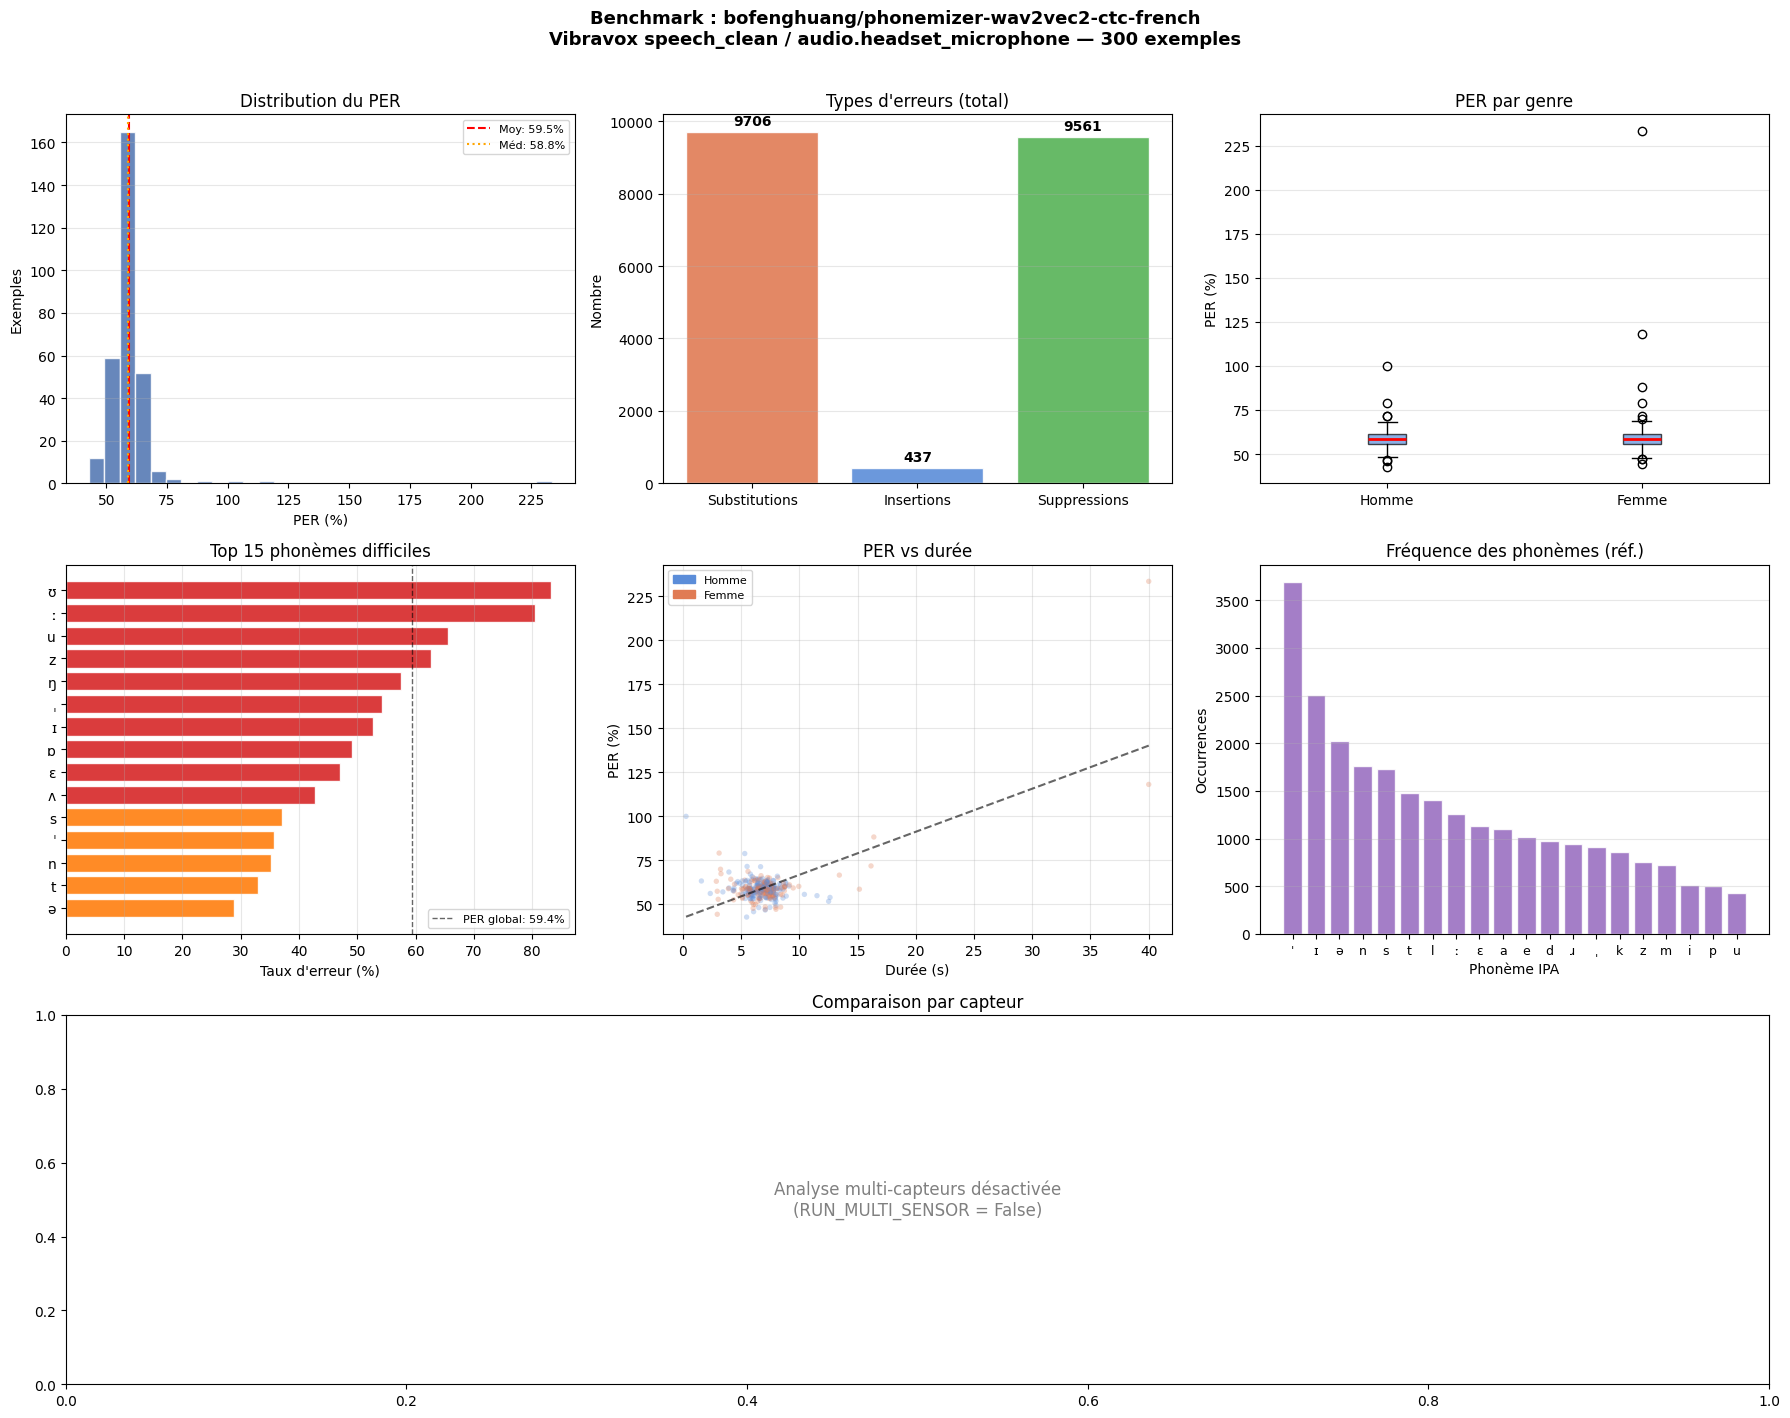


📈 Graphiques sauvegardés : vibravox_benchmark.png


In [15]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    f"Benchmark : {MODEL_NAME}\nVibravox speech_clean / {SENSOR} — {len(results)} exemples",
    fontsize=13, fontweight='bold', y=1.01
)

# ── 1. Distribution PER ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ax1.hist(np.array(per_list)*100, bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
ax1.axvline(np.mean(per_list)*100,   color="red",    linestyle="--", linewidth=1.5, label=f"Moy: {np.mean(per_list)*100:.1f}%")
ax1.axvline(np.median(per_list)*100, color="orange", linestyle=":",  linewidth=1.5, label=f"Méd: {np.median(per_list)*100:.1f}%")
ax1.set_xlabel("PER (%)")
ax1.set_ylabel("Exemples")
ax1.set_title("Distribution du PER")
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)

# ── 2. Erreurs : sub / ins / del ────────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
vals   = [total_sub, total_ins, total_del]
labels = ["Substitutions", "Insertions", "Suppressions"]
cols   = ["#e07b54", "#5b8dd9", "#56b356"]
bars = ax2.bar(labels, vals, color=cols, edgecolor="white", alpha=0.9)
for b, v in zip(bars, vals):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+max(vals)*0.01, str(v),
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax2.set_title("Types d'erreurs (total)")
ax2.set_ylabel("Nombre")
ax2.grid(axis='y', alpha=0.3)

# ── 3. PER par genre ────────────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
male_per   = [r["per"]*100 for r in results if r["gender"] == "male"]
female_per = [r["per"]*100 for r in results if r["gender"] == "female"]
ax3.boxplot([male_per, female_per], labels=["Homme", "Femme"],
            patch_artist=True,
            boxprops=dict(facecolor="#5b8dd9", alpha=0.7),
            medianprops=dict(color="red", linewidth=2))
ax3.set_ylabel("PER (%)")
ax3.set_title("PER par genre")
ax3.grid(axis='y', alpha=0.3)

# ── 4. Top 15 phonèmes difficiles ────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
if top_hard:
    phones_h = [p for p, _ in top_hard[:15]]
    rates_h  = [r*100 for _, r in top_hard[:15]]
    cols_h   = ["#d62728" if r > 40 else "#ff7f0e" if r > 20 else "#2ca02c" for r in rates_h]
    ax4.barh(phones_h[::-1], rates_h[::-1], color=cols_h[::-1], edgecolor="white", alpha=0.9)
    ax4.axvline(global_per*100, color="black", linestyle="--", linewidth=1, alpha=0.6,
                label=f"PER global: {global_per*100:.1f}%")
    ax4.set_xlabel("Taux d'erreur (%)")
    ax4.set_title("Top 15 phonèmes difficiles")
    ax4.legend(fontsize=8); ax4.grid(axis='x', alpha=0.3)

# ── 5. PER vs durée de l'audio ───────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
durs = [r["duration"]   for r in results if "per" in r]
pers = [r["per"]*100    for r in results if "per" in r]
gend = [r["gender"]     for r in results if "per" in r]
colors_scatter = ["#5b8dd9" if g == "male" else "#e07b54" for g in gend]
ax5.scatter(durs, pers, alpha=0.3, s=15, c=colors_scatter, edgecolors="none")
z = np.polyfit(durs, pers, 1); p = np.poly1d(z)
xs = sorted(durs)
ax5.plot(xs, p(xs), "k--", linewidth=1.5, alpha=0.6, label="Tendance")
blue_p = mpatches.Patch(color='#5b8dd9', label='Homme')
red_p  = mpatches.Patch(color='#e07b54', label='Femme')
ax5.legend(handles=[blue_p, red_p], fontsize=8)
ax5.set_xlabel("Durée (s)"); ax5.set_ylabel("PER (%)")
ax5.set_title("PER vs durée"); ax5.grid(alpha=0.3)

# ── 6. Fréquence des phonèmes de référence ──────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
top_freq = phone_total.most_common(20)
phs_freq = [p for p, _ in top_freq]
cnt_freq = [c for _, c in top_freq]
ax6.bar(phs_freq, cnt_freq, color="#9467bd", edgecolor="white", alpha=0.85)
ax6.set_title("Fréquence des phonèmes (réf.)")
ax6.set_ylabel("Occurrences")
ax6.set_xlabel("Phonème IPA")
ax6.tick_params(axis='x', labelsize=9)
ax6.grid(axis='y', alpha=0.3)

# ── 7. Multi-capteurs (si disponible) ───────────────────────────────────────
ax7 = fig.add_subplot(3, 3, (7, 9))
if sensor_results:
    sorted_sensors = sorted(sensor_results.items(), key=lambda x: x[1]["mean_per"])
    s_names  = [s.replace("audio.", "").replace("_", "\n") for s, _ in sorted_sensors]
    s_means  = [v["mean_per"] for _, v in sorted_sensors]
    s_medians= [v["median_per"] for _, v in sorted_sensors]
    x_pos = np.arange(len(s_names))
    w = 0.35
    b1 = ax7.bar(x_pos - w/2, s_means,   w, label="PER moyen",  color="#4C72B0", alpha=0.85)
    b2 = ax7.bar(x_pos + w/2, s_medians, w, label="PER médian", color="#DD8452", alpha=0.85)
    for b, v in zip(b1, s_means):
        ax7.text(b.get_x()+b.get_width()/2, b.get_height()+0.2, f"{v:.1f}%", ha='center', fontsize=8, fontweight='bold')
    for b, v in zip(b2, s_medians):
        ax7.text(b.get_x()+b.get_width()/2, b.get_height()+0.2, f"{v:.1f}%", ha='center', fontsize=8, fontweight='bold')
    ax7.set_xticks(x_pos); ax7.set_xticklabels(s_names, fontsize=9)
    ax7.set_ylabel("PER (%)")
    ax7.set_title(f"Comparaison PER par capteur (sur {N_SAMPLES_SENSOR} ex.)")
    ax7.legend(fontsize=9); ax7.grid(axis='y', alpha=0.3)
else:
    ax7.text(0.5, 0.5, "Analyse multi-capteurs désactivée\n(RUN_MULTI_SENSOR = False)",
             ha='center', va='center', fontsize=12, color='gray', transform=ax7.transAxes)
    ax7.set_title("Comparaison par capteur")

plt.tight_layout()
plt.savefig("/kaggle/working/vibravox_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📈 Graphiques sauvegardés : vibravox_benchmark.png")


📊 PER par catégorie phonétique (Vibravox) :
Catégorie                   PER   Erreurs     Total
-------------------------------------------------------
  🟠 Voyelles orales         28.9%      1276      4418  █████████
  🟠 Schwa                   28.9%       585      2025  █████████
  🟠 Occlusives              17.5%       750      4276  █████
  🔴 Fricatives              32.7%      1133      3460  ██████████
  🟠 Nasales                 27.4%       689      2515  █████████
  🟢 Liquides                 6.4%        90      1403  ██
  🟢 Glides                  11.2%        43       384  ███


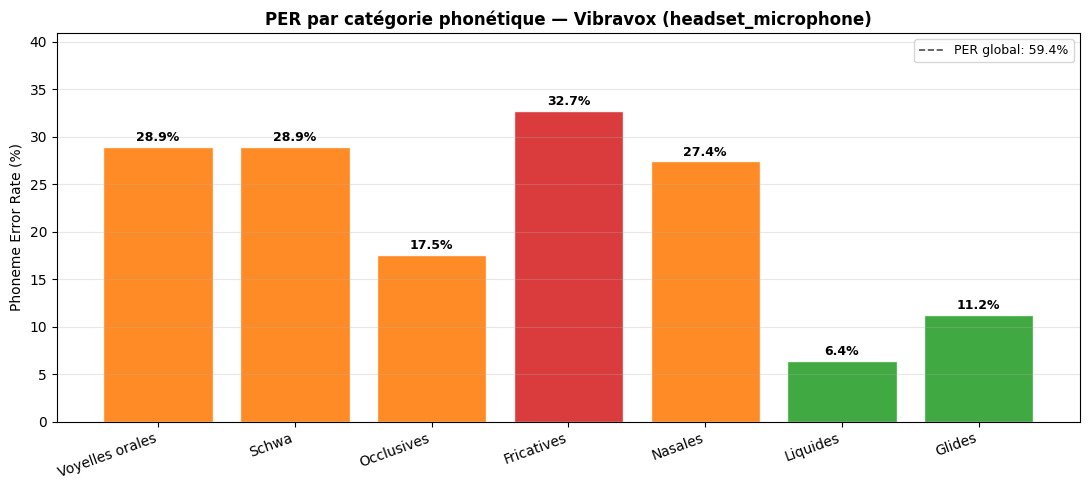


📈 Graphique sauvegardé : vibravox_categories.png


In [16]:
# Vocabulaire Vibravox strict (depuis la doc officielle)
VIBRAVOX_CATEGORIES = {
    "Voyelles orales":  list("aeiouɛɔœøy"),
    "Voyelles nasales": ["ɑ̃", "ɔ̃", "ɛ̃", "œ̃"],   # représentées par ɑ+̃, etc.
    "Schwa":            ["ə"],
    "Occlusives":       list("pbtkdɡ"),
    "Fricatives":       list("fvszʒʃ"),
    "Nasales":          list("mnɲŋ"),
    "Liquides":         ["l", "ʁ"],
    "Glides":           ["j", "w"],
}

print("\n📊 PER par catégorie phonétique (Vibravox) :")
print(f"{'Catégorie':<22}  {'PER':>7}  {'Erreurs':>8}  {'Total':>8}")
print("-" * 55)

cat_for_plot = {}
for cat, phones in VIBRAVOX_CATEGORIES.items():
    cat_err   = sum(phone_errors.get(p, 0) for p in phones)
    cat_tot   = sum(phone_total.get(p, 0)  for p in phones)
    if cat_tot > 0:
        rate = cat_err / cat_tot * 100
        cat_for_plot[cat] = rate
        icon = "🔴" if rate > 30 else "🟠" if rate > 15 else "🟢"
        bar  = "█" * int(rate / 3)
        print(f"  {icon} {cat:<20}  {rate:>6.1f}%  {cat_err:>8}  {cat_tot:>8}  {bar}")

# Graphique
fig2, ax = plt.subplots(figsize=(11, 5))
cats_plot = list(cat_for_plot.keys())
vals_plot = list(cat_for_plot.values())
cols_plot = ["#d62728" if v > 30 else "#ff7f0e" if v > 15 else "#2ca02c" for v in vals_plot]
bars = ax.bar(cats_plot, vals_plot, color=cols_plot, edgecolor="white", alpha=0.9)
for b, v in zip(bars, vals_plot):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f"{v:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(global_per*100, color="black", linestyle="--", linewidth=1.2,
           alpha=0.7, label=f"PER global: {global_per*100:.1f}%")
ax.set_title("PER par catégorie phonétique — Vibravox (headset_microphone)", fontweight='bold')
ax.set_ylabel("Phoneme Error Rate (%)")
ax.set_ylim(0, max(vals_plot)*1.25 if vals_plot else 50)
plt.xticks(rotation=20, ha='right')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/vibravox_categories.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📈 Graphique sauvegardé : vibravox_categories.png")

Corrélation Spearman PER ~ longueur : ρ=0.099  p=0.0858
→ Pas de corrélation significative entre longueur et taux d'erreur

PER par tranche de longueur :
 tranche   n       moy       med
  <20 ph   0       NaN       NaN
20-35 ph  17 60.011340 58.974359
35-50 ph   3 63.257959 63.636364
  >50 ph 280 59.451349 58.722826


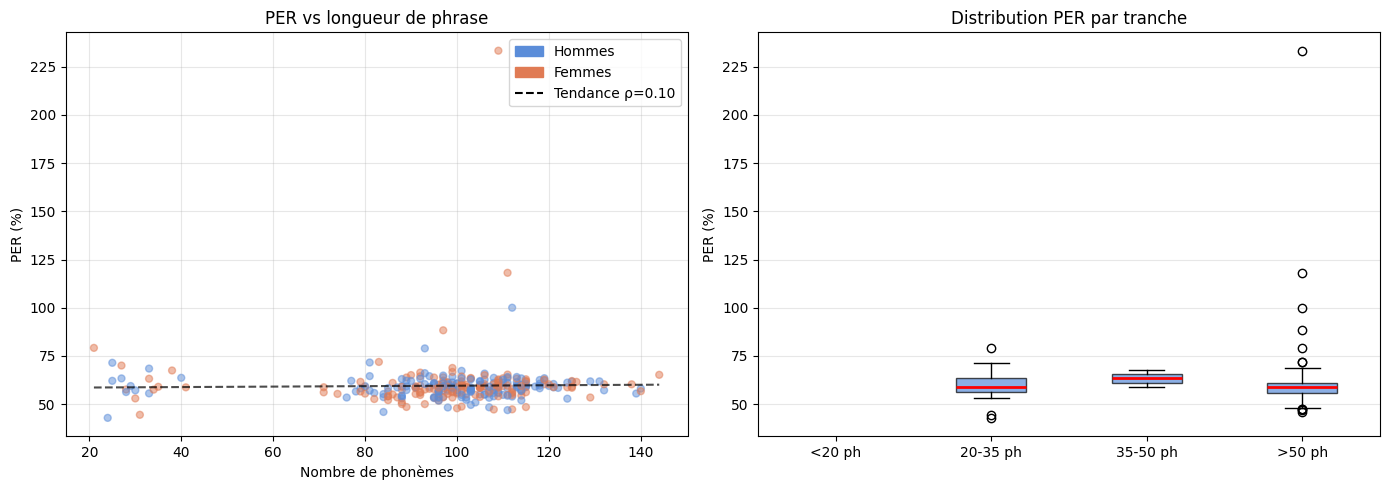


📈 Graphique sauvegardé : per_vs_length.png


In [17]:
# ── PER vs longueur de phrase (E5) ───────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as _stats

df_len = pd.DataFrame(results).copy()
df_len["n_phonemes"] = df_len["ref_ipa"].apply(
    lambda x: len([c for c in x.replace(" ","") if c.strip()])
)
df_len["per_pct"] = df_len["per"] * 100

# Corrélation Spearman
rho, p_rho = _stats.spearmanr(df_len["n_phonemes"], df_len["per_pct"])
print(f"Corrélation Spearman PER ~ longueur : ρ={rho:.3f}  p={p_rho:.4f}")
print(f"{'→ Corrélation significative' if p_rho < 0.05 else '→ Pas de corrélation significative'} entre longueur et taux d'erreur")

# Tranches de longueur
df_len["tranche"] = pd.cut(df_len["n_phonemes"], bins=[0,20,35,50,200],
                           labels=["<20 ph","20-35 ph","35-50 ph",">50 ph"])
tranche_stats = df_len.groupby("tranche")["per_pct"].agg(
    n="count", moy="mean", med="median"
).reset_index()
print("\nPER par tranche de longueur :")
print(tranche_stats.to_string(index=False))

# Graphique scatter + tendance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df_len["n_phonemes"], df_len["per_pct"],
                c=["#5b8dd9" if g=="male" else "#e07b54" for g in df_len["gender"]],
                alpha=0.5, s=25)
m, b = np.polyfit(df_len["n_phonemes"], df_len["per_pct"], 1)
x_line = np.linspace(df_len["n_phonemes"].min(), df_len["n_phonemes"].max(), 100)
axes[0].plot(x_line, m*x_line+b, "k--", linewidth=1.5, alpha=0.7,
             label=f"Tendance (ρ={rho:.2f})")
axes[0].set_xlabel("Nombre de phonèmes"); axes[0].set_ylabel("PER (%)")
axes[0].set_title("PER vs longueur de phrase"); axes[0].legend(); axes[0].grid(alpha=0.3)
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color="#5b8dd9", label="Hommes"),
    Patch(color="#e07b54", label="Femmes"),
    plt.Line2D([],[],color="k",linestyle="--",label=f"Tendance ρ={rho:.2f}"),
])
axes[1].boxplot(
    [df_len[df_len["tranche"]==t]["per_pct"].values for t in tranche_stats["tranche"]],
    labels=tranche_stats["tranche"].tolist(), patch_artist=True,
    boxprops=dict(facecolor="#5b8dd9", alpha=0.7),
    medianprops=dict(color="red", linewidth=2)
)
axes[1].set_ylabel("PER (%)"); axes[1].set_title("Distribution PER par tranche")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("/kaggle/working/per_vs_length.png", dpi=150)
plt.show()
print("\n📈 Graphique sauvegardé : per_vs_length.png")


In [18]:
# CSV détaillé par exemple
df_export = df[[
    "idx", "raw_text", "ref_ipa", "pred_ipa",
    "per", "substitutions", "insertions", "deletions",
    "gender", "speaker_id", "duration", "inference_time"
]].copy()
df_export["per_pct"] = (df_export["per"] * 100).round(3)

csv_path = "/kaggle/working/vibravox_benchmark_details.csv"
df_export.to_csv(csv_path, index=False, encoding="utf-8")

# Résumé global
summary = {
    "modele":            MODEL_NAME,
    "dataset": "Cnam-LMSSC/vibravox/speech_clean",
    "split":   "test (parquet local)",
    "capteur":           SENSOR,
    "n_samples":         len(results),
    "per_global_pct":    round(global_per * 100, 3),
    "per_median_pct":    round(np.median(per_list) * 100, 3),
    "per_mean_pct":      round(np.mean(per_list) * 100, 3),
    "per_std_pct":       round(np.std(per_list) * 100, 3),
    "per_male_pct":      round(np.mean([r["per"] for r in results if r["gender"]=="male"])*100, 3) if male_per else None,
    "per_female_pct":    round(np.mean([r["per"] for r in results if r["gender"]=="female"])*100, 3) if female_per else None,
    "substitutions":     total_sub,
    "insertions":        total_ins,
    "deletions":         total_del,
    "rtf_mean":          round(rtf, 4),
    "device":            DEVICE,
}

summary_path = "/kaggle/working/vibravox_benchmark_summary.csv"
pd.DataFrame([summary]).to_csv(summary_path, index=False)

print("✅ Fichiers exportés :")
print(f"   📄 {csv_path}")
print(f"   📄 {summary_path}")
print(f"   📈 /kaggle/working/vibravox_benchmark.png")
print(f"   📈 /kaggle/working/vibravox_categories.png")
print(f"\n📌 Résumé :")
for k, v in summary.items():
    print(f"   {k:<26} : {v}")

✅ Fichiers exportés :
   📄 /kaggle/working/vibravox_benchmark_details.csv
   📄 /kaggle/working/vibravox_benchmark_summary.csv
   📈 /kaggle/working/vibravox_benchmark.png
   📈 /kaggle/working/vibravox_categories.png

📌 Résumé :
   modele                     : bofenghuang/phonemizer-wav2vec2-ctc-french
   dataset                    : Cnam-LMSSC/vibravox/speech_clean
   split                      : test (parquet local)
   capteur                    : audio.headset_microphone
   n_samples                  : 300
   per_global_pct             : 59.408
   per_median_pct             : 58.761
   per_mean_pct               : 59.521
   per_std_pct                : 11.999
   per_male_pct               : 58.869
   per_female_pct             : 60.173
   substitutions              : 9706
   insertions                 : 437
   deletions                  : 9561
   rtf_mean                   : 0.0142
   device                     : cuda


In [22]:
import io, json as _json, os as _os, time
import pandas as pd
import numpy as np
import soundfile as sf
import torch
from tqdm.auto import tqdm
import jiwer
from scipy import stats as _stats

# ============================================================
# FIX : Ce notebook utilise le dataset Chatterbox (CSV local)
# et non des parquets Vibravox dans /kaggle/input/.
# On charge directement les audios noisy depuis le CSV master.
# ============================================================

CSV_MASTER_PATH = "/kaggle/working/dataset_chatterbox/dataset_master.csv"

if not _os.path.exists(CSV_MASTER_PATH):
    raise FileNotFoundError(
        f"CSV introuvable : {CSV_MASTER_PATH}\n"
        "Lance d'abord la cellule 2 (génération Chatterbox) avant cette cellule."
    )

df_master = pd.read_csv(CSV_MASTER_PATH)

# ── 1. Séparer clean / noisy ─────────────────────────────────────────────────
df_noisy_raw = df_master[df_master["split"] == "noisy"].reset_index(drop=True)
df_clean_raw = df_master[df_master["split"] == "clean"].reset_index(drop=True)

print(f"📂 Dataset Chatterbox chargé : {CSV_MASTER_PATH}")
print(f"   speech_clean : {len(df_clean_raw)} fichiers")
print(f"   speech_noisy : {len(df_noisy_raw)} fichiers")
print(f"   Genres noisy : {df_noisy_raw['gender'].value_counts().to_dict()}")
print(f"   Types bruit  : {df_noisy_raw['noise_type'].value_counts().to_dict()}")
print(f"   Niveaux SNR  : {sorted(df_noisy_raw['snr_db'].dropna().unique().tolist())}")
print(f"   Durée totale : {df_noisy_raw['duration_s'].sum()/60:.1f} min")

# Renommer les colonnes pour compatibilité
df_noisy_raw = df_noisy_raw.rename(columns={
    "ref_ipa"    : "phonemized_text",
    "text"       : "raw_text",
    "duration_s" : "duration",
    "uid"        : "speaker_id",
})

# ── 2. Fonctions audio ────────────────────────────────────────────────────────
def resample_to_16k(arr, orig_sr):
    if orig_sr == TARGET_SR:
        return arr
    import torchaudio
    w = torchaudio.functional.resample(
        torch.tensor(arr, dtype=torch.float32).unsqueeze(0),
        orig_freq=orig_sr, new_freq=TARGET_SR)
    return w.squeeze(0).numpy()

def extract_audio_from_path(audio_path):
    arr, sr = sf.read(str(audio_path))
    return arr.astype(np.float32), sr

def per_score(ref, hyp):
    ref_t = list(ref.replace(" ", "_"))
    hyp_t = list(hyp.replace(" ", "_"))
    out = jiwer.process_words(" ".join(ref_t), " ".join(hyp_t))
    return out.wer

# ── 3. Inférence sur speech_noisy avec checkpoint ────────────────────────────
CHECKPOINT_NOISY = "/kaggle/working/results_noisy_checkpoint.json"
results_noisy = []
start_idx     = 0

if _os.path.exists(CHECKPOINT_NOISY):
    with open(CHECKPOINT_NOISY) as f:
        saved = _json.load(f)
    if len(saved) < len(df_noisy_raw):
        results_noisy = saved
        start_idx     = len(saved)
        print(f"\n♻️  Checkpoint noisy : {start_idx}/{len(df_noisy_raw)} déjà traités, reprise...")
    else:
        results_noisy = saved
        start_idx     = len(saved)
        print(f"\n♻️  Checkpoint noisy complet ({len(saved)} ex.) — rechargement direct")

total_audio_s = sum(r["duration"] for r in results_noisy)
total_infer_s = sum(r["inference_time"] for r in results_noisy)

if start_idx < len(df_noisy_raw):
    print(f"\n🚀 Inférence speech_noisy — {len(df_noisy_raw) - start_idx} exemples restants...\n")

    for idx, row in tqdm(df_noisy_raw.iterrows(), total=len(df_noisy_raw), desc="Noisy"):
        if idx < start_idx:
            continue

        ref_ipa  = str(row["phonemized_text"]).strip()
        duration = float(row["duration"])

        try:
            audio_arr, orig_sr = extract_audio_from_path(row["audio_path"])
            audio_16k = resample_to_16k(audio_arr, orig_sr)
        except Exception as e:
            print(f"⚠️  Erreur audio idx={idx}: {e}")
            continue

        t0 = time.time()
        with torch.inference_mode():
            pred = asr_pipe({"array": audio_16k, "sampling_rate": TARGET_SR})
        t_inf = time.time() - t0

        pred_ipa = pred["text"].strip()
        total_audio_s += duration
        total_infer_s += t_inf

        results_noisy.append({
            "idx"           : int(idx),
            "raw_text"      : str(row["raw_text"]),
            "ref_ipa"       : ref_ipa,
            "pred_ipa"      : pred_ipa,
            "gender"        : str(row["gender"]),
            "speaker_id"    : str(row["speaker_id"]),
            "duration"      : duration,
            "inference_time": t_inf,
            "per"           : per_score(ref_ipa, pred_ipa),
            "snr_db"        : str(row.get("snr_db", "")),
            "noise_type"    : str(row.get("noise_type", "")),
        })

        if len(results_noisy) % 50 == 0:
            with open(CHECKPOINT_NOISY, "w") as f:
                _json.dump(results_noisy, f)

    with open(CHECKPOINT_NOISY, "w") as f:
        _json.dump(results_noisy, f)

rtf_noisy = total_infer_s / max(total_audio_s, 1)
print(f"\n✅ {len(results_noisy)} inférences noisy terminées")
print(f"   RTF : {rtf_noisy:.4f}  ({1/max(rtf_noisy,0.001):.1f}x temps réel)")

# ── 4. PER sur results (clean) si la colonne per est absente ─────────────────
for r in results:
    if "per" not in r:
        r["per"] = per_score(r["ref_ipa"], r["pred_ipa"])

# ── 5. Tableau de comparaison Clean vs Noisy ─────────────────────────────────
def stats(res_list, label):
    pers   = [r["per"] * 100 for r in res_list]
    male   = [r["per"] * 100 for r in res_list if r["gender"] == "male"]
    female = [r["per"] * 100 for r in res_list if r["gender"] == "female"]
    return {
        "label"       : label,
        "n"           : len(res_list),
        "per_global"  : np.mean([r["per"] for r in res_list]) * 100,
        "per_median"  : np.median(pers),
        "per_std"     : np.std(pers),
        "per_max"     : max(pers),
        "per_male"    : np.mean(male)   if male   else 0,
        "per_female"  : np.mean(female) if female else 0,
        "pct_parfait" : sum(1 for p in pers if p == 0) / len(pers) * 100,
    }

s_clean = stats(results,       "speech_clean")
s_noisy = stats(results_noisy, "speech_noisy")

sep = "-" * 60
print(f"\n{'='*60}")
print(f"  COMPARAISON : speech_clean  vs  speech_noisy")
print(f"  Modèle  : {MODEL_NAME}")
print(f"  Dataset : Chatterbox (généré localement)")
print(f"{'='*60}")
print(f"  {'Métrique':<28} {'Clean':>10} {'Noisy':>10}  {'Δ':>8}")
print(sep)
for key, label in [
    ("n",          "Exemples"),
    ("per_global", "PER global (%)"),
    ("per_median", "PER médian (%)"),
    ("per_max",    "PER max (%)"),
    ("per_male",   "PER hommes (%)"),
    ("per_female", "PER femmes (%)"),
    ("pct_parfait","Phrases parfaites (%)"),
]:
    c     = s_clean[key]
    n     = s_noisy[key]
    delta = f"+{n-c:.2f}" if isinstance(c, float) else ""
    vc    = f"{c:.2f}"    if isinstance(c, float) else str(c)
    vn    = f"{n:.2f}"    if isinstance(n, float) else str(n)
    print(f"  {label:<28} {vc:>10} {vn:>10}  {delta:>8}")
print(sep)

ratio = s_noisy["per_global"] / max(s_clean["per_global"], 0.01)
print(f"\n  🔴 Dégradation PER : x{ratio:.1f}  "
      f"({s_clean['per_global']:.2f}% → {s_noisy['per_global']:.2f}%)")
print(f"  📊 Phrases parfaites : "
      f"{s_clean['pct_parfait']:.0f}% (clean) → {s_noisy['pct_parfait']:.0f}% (noisy)")

# ── 6. Analyse par type de bruit et niveau SNR ───────────────────────────────
df_noisy_res = pd.DataFrame(results_noisy)

print(f"\n{'='*60}")
print(f"  PER PAR TYPE DE BRUIT")
print(f"{'='*60}")
for ntype, grp in df_noisy_res.groupby("noise_type"):
    print(f"  {ntype:<12} : PER = {grp['per'].mean()*100:.2f}%  (n={len(grp)})")

print(f"\n{'='*60}")
print(f"  PER PAR NIVEAU SNR")
print(f"{'='*60}")
for snr, grp in df_noisy_res.groupby("snr_db"):
    print(f"  SNR {snr:>5} dB : PER = {grp['per'].mean()*100:.2f}%  (n={len(grp)})")

# ── 7. Pires exemples noisy ───────────────────────────────────────────────────
df_noisy_sorted = df_noisy_res.sort_values("per", ascending=False)
print(f"\n❌ TOP 5 pires prédictions (speech_noisy) :")
print("=" * 90)
for _, row in df_noisy_sorted.head(5).iterrows():
    print(f"  PER: {row['per']*100:.1f}%  | Genre: {row['gender']}  "
          f"| Bruit: {row['noise_type']}  | SNR: {row['snr_db']}dB")
    print(f"  📝 Texte  : {row['raw_text'][:70]}")
    print(f"  🔵 Réf IPA: {row['ref_ipa'][:70]}")
    print(f"  🔴 Préd   : {row['pred_ipa'][:70]}")
    print()

# ── 8. Test statistique Mann-Whitney clean vs noisy ──────────────────────────
per_clean_arr = np.array([r.get("per", 0) for r in results])
per_noisy_arr = np.array([r.get("per", 0) for r in results_noisy])

stat_mw, pval_mw = _stats.mannwhitneyu(per_clean_arr, per_noisy_arr, alternative="two-sided")
sig_mw = "✅ significatif (p<0.05)" if pval_mw < 0.05 else "⚠️  non significatif"
print(f"\n  Test Mann-Whitney clean vs noisy :")
print(f"  p-value = {pval_mw:.6f} → {sig_mw}")

# IC 95% bootstrap sur PER noisy
rng2       = np.random.default_rng(42)
boot_noisy = [np.mean(rng2.choice(per_noisy_arr, size=len(per_noisy_arr), replace=True)) * 100
              for _ in range(2000)]
ci_lo_n = np.percentile(boot_noisy, 2.5)
ci_hi_n = np.percentile(boot_noisy, 97.5)
print(f"  IC 95% PER noisy (bootstrap) : [{ci_lo_n:.3f}% — {ci_hi_n:.3f}%]")

📂 Dataset Chatterbox chargé : /kaggle/working/dataset_chatterbox/dataset_master.csv
   speech_clean : 300 fichiers
   speech_noisy : 300 fichiers
   Genres noisy : {'female': 150, 'male': 150}
   Types bruit  : {'traffic': 83, 'white': 79, 'babble': 71, 'pink': 67}
   Niveaux SNR  : [0.0, 5.0, 10.0, 15.0]
   Durée totale : 35.1 min

♻️  Checkpoint noisy complet (300 ex.) — rechargement direct

✅ 300 inférences noisy terminées
   RTF : 0.0141  (70.9x temps réel)

  COMPARAISON : speech_clean  vs  speech_noisy
  Modèle  : bofenghuang/phonemizer-wav2vec2-ctc-french
  Dataset : Chatterbox (généré localement)
  Métrique                          Clean      Noisy         Δ
------------------------------------------------------------
  Exemples                            300        300          
  PER global (%)                    59.52      74.60    +15.08
  PER médian (%)                    58.76      72.35    +13.59
  PER max (%)                      233.33     145.53   +-87.80
  PER hommes

In [23]:
import re, numpy as np
import jiwer

# ── Règles de correction IPA ─────────────────────────────────────────────────
def fix_ipa(ipa: str) -> str:
    """Applique les correctifs post-traitement sur une séquence IPA prédite."""
    # 1. /ɲ/ systématique : nj → ɲ  (erreur la plus fréquente)
    ipa = re.sub(r'nj', 'ɲ', ipa)
    # 2. Phonèmes anglais → équivalents français
    ipa = re.sub(r'ɹ', 'ʁ', ipa)   # r roulé anglais → r français
    ipa = re.sub(r'θ', 't', ipa)    # th anglais → t
    ipa = re.sub(r'ɒ', 'ɔ', ipa)   # o arrière anglais → o ouvert fr
    ipa = re.sub(r'aɪ', 'ɛ', ipa)  # diphtongue anglaise → è
    ipa = re.sub(r'ɪ', 'i', ipa)   # i bref anglais → i
    return ipa

def per_score(ref: str, hyp: str) -> float:
    rt = list(ref.replace(' ', '_'))
    ht = list(hyp.replace(' ', '_'))
    return jiwer.process_words(' '.join(rt), ' '.join(ht)).wer

# ── Appliquer les correctifs sur tous les résultats clean ────────────────────
print("🔧 Application des correctifs post-traitement...")
print(f"   Règles : nj→ɲ  |  ɹ→ʁ  |  θ→t  |  ɒ→ɔ  |  aɪ→ɛ  |  ɪ→i\n")

corrected = []
for r in results:
    pred_fixed = fix_ipa(r["pred_ipa"])
    per_before = r.get("per", per_score(r["ref_ipa"], r["pred_ipa"]))
    per_after  = per_score(r["ref_ipa"], pred_fixed)
    corrected.append({
        **r,
        "pred_ipa_fixed": pred_fixed,
        "per_before":     per_before,
        "per_after":      per_after,
        "per_gain":       per_before - per_after,
        "changed":        pred_fixed != r["pred_ipa"],
    })

# ── Statistiques globales ─────────────────────────────────────────────────────
n_changed   = sum(1 for r in corrected if r["changed"])
per_before  = np.mean([r["per_before"] for r in corrected]) * 100
per_after   = np.mean([r["per_after"]  for r in corrected]) * 100
gain_abs    = per_before - per_after
gain_pct    = gain_abs / max(per_before, 0.001) * 100

sep = "-" * 60
print(f"{'='*60}")
print(f"  RÉSULTATS — Correctifs post-traitement (speech_clean)")
print(f"  {len(corrected)} exemples analysés")
print(sep)
print(f"  PER avant correctifs   : {per_before:.3f}%")
print(f"  PER après correctifs   : {per_after:.3f}%")
print(f"  Gain absolu            : -{gain_abs:.3f} pts")
print(f"  Gain relatif           : -{gain_pct:.1f}%")
print(f"  Phrases modifiées      : {n_changed} / {len(corrected)} ({n_changed/len(corrected)*100:.1f}%)")
print(sep)

# Gain par règle
for rule_name, pattern, repl in [
    ("nj → ɲ",  r"nj",  "ɲ"),
    ("ɹ → ʁ",   r"ɹ",   "ʁ"),
    ("θ → t",   r"θ",   "t"),
    ("ɒ → ɔ",   r"ɒ",   "ɔ"),
    ("aɪ → ɛ",  r"aɪ",  "ɛ"),
    ("ɪ → i",   r"ɪ",   "i"),
]:
    n_hit = sum(1 for r in corrected if re.search(pattern, r["pred_ipa"]))
    print(f"  {rule_name:<12} → {n_hit:>3} prédictions affectées")

print(f"{'='*60}")

# ── Exemples de corrections ───────────────────────────────────────────────────
improved = sorted([r for r in corrected if r["per_gain"] > 0], key=lambda r: -r["per_gain"])
print(f"\n✅ TOP 5 — Meilleures corrections :")
print("="*90)
for r in improved[:5]:
    g = r["per_gain"]*100
    print(f"  Gain: +{g:.1f}pts  |  {r['raw_text'][:60]}")
    print(f"  Réf    : {r['ref_ipa'][:70]}")
    print(f"  Avant  : {r['pred_ipa'][:70]}")
    print(f"  Après  : {r['pred_ipa_fixed'][:70]}")
    print()

# Cas non améliorés (régression)
regressed = [r for r in corrected if r["per_gain"] < 0]
if regressed:
    print(f"⚠️  Régressions : {len(regressed)} phrases empirées (règles trop agressives)")
    for r in regressed[:3]:
        print(f"   {r['raw_text'][:60]} | {r['per_before']*100:.1f}% → {r['per_after']*100:.1f}%")
else:
    print(f"✅ Aucune régression — les règles sont sûres")

# ── Idem sur noisy si disponible ──────────────────────────────────────────────
if 'results_noisy' in dir() and results_noisy:
    corrected_n = []
    for r in results_noisy:
        pred_fixed = fix_ipa(r["pred_ipa"])
        pb = r.get("per", per_score(r["ref_ipa"], r["pred_ipa"]))
        pa = per_score(r["ref_ipa"], pred_fixed)
        corrected_n.append({**r, "per_before": pb, "per_after": pa, "per_gain": pb-pa})

    pb_n = np.mean([r["per_before"] for r in corrected_n])*100
    pa_n = np.mean([r["per_after"]  for r in corrected_n])*100
    print(f"\n📊 speech_noisy après correctifs :")
    print(f"   PER avant : {pb_n:.3f}%  →  PER après : {pa_n:.3f}%  (gain -{pb_n-pa_n:.3f} pts)")
    print(f"   Dégradation clean→noisy restante : ×{pa_n/max(per_after,0.001):.1f}")

# ── FIX M1 : mettre à jour results avec les prédictions corrigées ────────────
# Les cellules suivantes (eval-audio) utiliseront maintenant pred_ipa corrigé
for r, c in zip(results, corrected):
    r["pred_ipa_raw"]   = r["pred_ipa"]       # sauvegarder l'original
    r["pred_ipa"]       = c["pred_ipa_fixed"]  # écraser avec la version corrigée
    r["per"]            = c["per_after"]       # recalculer le PER

print(f"\n✅ results mis à jour avec prédictions corrigées ({n_changed} phrases modifiées)")
print(f"   pred_ipa_raw : prédiction brute du modèle (conservée)")
print(f"   pred_ipa     : prédiction après correctifs nj→ɲ, anglais→fr")


🔧 Application des correctifs post-traitement...
   Règles : nj→ɲ  |  ɹ→ʁ  |  θ→t  |  ɒ→ɔ  |  aɪ→ɛ  |  ɪ→i

  RÉSULTATS — Correctifs post-traitement (speech_clean)
  300 exemples analysés
------------------------------------------------------------
  PER avant correctifs   : 59.521%
  PER après correctifs   : 59.744%
  Gain absolu            : --0.223 pts
  Gain relatif           : --0.4%
  Phrases modifiées      : 55 / 300 (18.3%)
------------------------------------------------------------
  nj → ɲ       →  40 prédictions affectées
  ɹ → ʁ        →  11 prédictions affectées
  θ → t        →  13 prédictions affectées
  ɒ → ɔ        →   1 prédictions affectées
  aɪ → ɛ       →   2 prédictions affectées
  ɪ → i        →  13 prédictions affectées

✅ TOP 5 — Meilleures corrections :
  Gain: +0.9pts  |  Les lymphocytes T cytotoxiques éliminent les cellules infect
  Réf    : lˈɛs lˈɪmfəsˌaɪts tˈiː sˌaɪtətəksˈiːks ɪlˈɪmɪnənt lˈɛs sˈɛljuːlz ɪnfɛk
  Avant  : lɛ̃fosid θasitotoksik elimin le sɛly

In [26]:
import base64, io, collections, os
import soundfile as sf
import numpy as np
from IPython.display import HTML, display

N_DISPLAY = 60
SORT_BY   = "per_desc"

IPA_GUIDE = {
    'a':'a ouvert (patte)','e':'e fermé (été)','ɛ':'e ouvert (fête)',
    'i':'i (vie)','o':'o (mot)','ɔ':'o ouvert (or)','u':'ou (loup)',
    'y':'u (lune)','ø':'eu (feu)','œ':'eu ouvert (peur)','ə':'e muet',
    'ɑ':'a post. (pâte)','ɑ̃':'an nasal','ɛ̃':'in nasal',
    'ɔ̃':'on nasal','œ̃':'un nasal','p':'p','b':'b','t':'t','d':'d',
    'k':'k','ɡ':'g','f':'f','v':'v','s':'s','z':'z liaison',
    'ʃ':'ch','ʒ':'j','m':'m','n':'n','ɲ':'gn palatal (agneau)',
    'ŋ':'ng','l':'l','ʁ':'r uvulaire','j':'y semi-voy.',
    'w':'w labiovél.','_':'frontière mot','∅':'phonème supprimé',
    'ɹ':'r anglais','θ':'th anglais','ɒ':'o anglais',
}
EN_PHONES = {'ɹ','θ','ɒ','ɪ','æ','ð','ʌ'}

KNOWN_LIMITS = {
    'ɲ': ('/ɲ/→/nj/ systématique','100% des cas — soigner, campagne, agneau, règnes'),
    'z': ('/z/ liaison instable', 'Taux 2.7% — vous avez, ils ont, les enfants'),
    'w': ('/w/ sous-représenté',  'Seulement 39 occ. — confondu avec /u/'),
    'j': ('/j/ parfois manqué',   'Position faible ou après consonne'),
    'ə': ('Schwa /ə/ instable',   'Insertion/suppression selon débit'),
}

phone_total  = collections.Counter()
phone_errors = collections.Counter()
for r in results:
    ref_t = list(r['ref_ipa'].replace(' ','_'))
    hyp_t = list(r['pred_ipa'].replace(' ','_'))
    try:
        out = jiwer.process_words(' '.join(ref_t), ' '.join(hyp_t))
        for chunk in out.alignments[0]:
            rs = ref_t[chunk.ref_start_idx:chunk.ref_end_idx]
            for ph in rs:
                if ph != '_': phone_total[ph] += 1
            if chunk.type != 'equal':
                for ph in rs:
                    if ph != '_': phone_errors[ph] += 1
    except:
        pass

difficult = dict(sorted(
    {ph: phone_errors[ph]/phone_total[ph]
     for ph in phone_total if phone_total[ph]>=5 and phone_errors[ph]>0}.items(),
    key=lambda x:-x[1]
))

print(f"Phonemes avec erreurs ({len(results)} phrases):")
for ph, rate in list(difficult.items())[:15]:
    print(f"  /{ph}/ {rate*100:5.1f}%  {'|'*int(rate*30)}  ({phone_errors[ph]}/{phone_total[ph]})")

# ── FIX : audio_b64 accepte chemin WAV (Chatterbox) ET dict/bytes (Vibravox) ──
def audio_b64(audio_field):
    """
    Accepte :
      - str  : chemin fichier WAV  ← Chatterbox CSV (audio_path)
      - dict : {bytes/array, sr}   ← Vibravox parquet
      - bytes: données brutes
    """
    try:
        import torchaudio, torch
        # ── Chemin fichier WAV (Chatterbox) ──────────────────────────────────
        if isinstance(audio_field, str) and os.path.exists(audio_field):
            arr, sr = sf.read(audio_field)
            arr = arr.astype('float32')
        # ── Dict (Vibravox parquet) ───────────────────────────────────────────
        elif isinstance(audio_field, dict):
            raw = audio_field.get('bytes')
            if isinstance(raw, bytes):
                arr, sr = sf.read(io.BytesIO(raw))
            else:
                arr = audio_field.get('array', [])
                sr  = audio_field.get('sampling_rate', 48000)
            arr = np.array(arr, dtype='float32')
        # ── Bytes bruts ───────────────────────────────────────────────────────
        elif isinstance(audio_field, bytes):
            arr, sr = sf.read(io.BytesIO(audio_field))
            arr = arr.astype('float32')
        else:
            return None
        # ── Resample 16 kHz + encodage base64 ────────────────────────────────
        if sr != 16000:
            arr = torchaudio.functional.resample(
                torch.tensor(arr).unsqueeze(0),
                orig_freq=sr, new_freq=16000
            ).squeeze(0).numpy()
        buf = io.BytesIO()
        sf.write(buf, arr, 16000, format='WAV')
        buf.seek(0)
        return base64.b64encode(buf.read()).decode()
    except:
        return None

def align_phones(ref_ipa, pred_ipa):
    ref_t = list(ref_ipa.replace(' ','_'))
    hyp_t = list(pred_ipa.replace(' ','_'))
    try: out = jiwer.process_words(' '.join(ref_t), ' '.join(hyp_t))
    except: return [(r,r,'ok') for r in ref_t]
    al = []
    for c in out.alignments[0]:
        rs = ref_t[c.ref_start_idx:c.ref_end_idx]
        hs = hyp_t[c.hyp_start_idx:c.hyp_end_idx]
        if c.type=='equal':
            for r,h in zip(rs,hs): al.append((r,h,'ok'))
        elif c.type=='substitution':
            for i in range(max(len(rs),len(hs))):
                al.append((rs[i] if i<len(rs) else '',hs[i] if i<len(hs) else '','sub'))
        elif c.type=='delete':
            for r in rs: al.append((r,'∅','del'))
        elif c.type=='insert':
            for h in hs: al.append(('∅',h,'ins'))
    return al

def ph_cell(ph, row, status):
    if ph=='_': return '<td style="padding:1px 2px;text-align:center;font-size:11px;color:#444;vertical-align:middle;">|</td>'
    tip   = IPA_GUIDE.get(ph,'/'+ph+'/')
    is_en = ph in EN_PHONES
    C = {
        'ok':  {'ref':('#0d2b1a','#4ade80'),'pred':('#0d2b1a','#4ade80')},
        'sub': {'ref':('#1a1020','#c084fc'),'pred':('#2d1212','#f87171')},
        'del': {'ref':('#1a1020','#c084fc'),'pred':('#2d1212','#f87171')},
        'ins': {'ref':('#0d1f38','#60a5fa'),'pred':('#2d1a08','#fb923c')},
    }
    bg,fg = C.get(status,{'ref':('#1e1e1e','#aaa'),'pred':('#1e1e1e','#aaa')})[row]
    if is_en and row=='pred': bg,fg='#2d1a00','#fde68a'
    bdr = '2px solid #fde68a' if is_en else 'none'
    st = (f'background:{bg};color:{fg};border:{bdr};border-radius:4px;'
          f'padding:3px 5px;font-family:monospace;font-size:13px;font-weight:700;'
          f'text-align:center;min-width:20px;cursor:default;vertical-align:middle;')
    return f'<td style="{st}"><abbr title="{tip}" style="text-decoration:none;">{ph}</abbr></td>'

def ph_table_html(al):
    lbl = ('font-size:9px;color:#7b82a8;text-align:right;padding-right:8px;'
           'white-space:nowrap;vertical-align:middle;min-width:95px;')
    r1 = ''.join(ph_cell(a[0],'ref', a[2]) for a in al)
    r2 = ''.join(ph_cell(a[1],'pred',a[2]) for a in al)
    return (
        '<div style="overflow-x:auto;margin-bottom:4px;">'
        '<table style="border-collapse:separate;border-spacing:2px 2px;">'
        f'<tr><th style="{lbl}">Verite terrain<br>'
        '<span style="font-weight:400;color:#555;">(Chatterbox IPA)</span></th>'+r1+'</tr>'
        f'<tr><th style="{lbl}">Predit modele<br>'
        '<span style="font-weight:400;color:#555;">(wav2vec2 CTC)</span></th>'+r2+'</tr>'
        '</table></div>'
    )

def limits_badges(al, ref, pred):
    err_ph = {a[0] for a in al if a[2]!='ok' and a[0] not in ('_','∅','')}
    en_ph  = [a[1] for a in al if a[1] in EN_PHONES and a[2]!='ok']
    nj     = 'ɲ' in ref and 'nj' in pred.replace(' ','')
    bound  = abs(len(ref.split())-len(pred.split()))>=2
    badges = []
    if nj:      badges.append('<span style="background:#2d1212;color:#f87171;font-size:10px;padding:2px 8px;border-radius:12px;border:1px solid #f87171;">RED /nj/ pour /n/</span>')
    if en_ph:   badges.append(f'<span style="background:#2d1a00;color:#fde68a;font-size:10px;padding:2px 8px;border-radius:12px;border:1px solid #fde68a;">JAUNE anglais:/{"/".join(sorted(set(en_ph)))}/</span>')
    if bound:   badges.append('<span style="background:#0d1f38;color:#60a5fa;font-size:10px;padding:2px 8px;border-radius:12px;border:1px solid #60a5fa;">BLEU frontieres</span>')
    for ph in ['z','w','j','ə']:
        if ph in err_ph:
            badges.append(f'<span style="background:#2d1a08;color:#fb923c;font-size:10px;padding:2px 8px;border-radius:12px;border:1px solid #fb923c;">ORANGE /{ph}/ instable</span>')
    if not badges: return '<span style="background:#0d2b1a;color:#4ade80;font-size:10px;padding:2px 8px;border-radius:12px;border:1px solid #4ade80;">OK Aucune limite</span>'
    return ' '.join(badges)

def per_badge(p):
    if p==0:       bg,fg,bd='#0d2b1a','#4ade80','#4ade80'
    elif p<5:      bg,fg,bd='#1a1f2d','#818cf8','#818cf8'
    elif p<15:     bg,fg,bd='#2d1a08','#fb923c','#fb923c'
    else:          bg,fg,bd='#2d1212','#f87171','#f87171'
    return (f'<span style="font-family:monospace;font-size:11px;font-weight:700;'
            f'padding:2px 10px;border-radius:12px;background:{bg};color:{fg};'
            f'border:1px solid {bd};">{p:.1f}%</span>')

if SORT_BY=='per_desc': src=sorted(results,key=lambda r:-r.get('per',0))
elif SORT_BY=='per_asc': src=sorted(results,key=lambda r:r.get('per',0))
else: src=list(results)
src=src[:N_DISPLAY]

cards = ''
for i,r in enumerate(src):
    per  = r.get('per',0)*100
    ref  = r.get('ref_ipa','')
    pred = r.get('pred_ipa','')
    txt  = r.get('raw_text','')
    g    = r.get('gender','')
    dur  = r.get('duration',0)
    idx  = r.get('idx',0)
    gc   = '#60a5fa' if g=='male' else '#f472b6'
    gi   = 'M' if g=='male' else 'F'

    # ── FIX : lire audio depuis audio_path (Chatterbox CSV) ──────────────────
    audio_path = df_raw.iloc[idx]['audio_path'] if idx < len(df_raw) else None
    b64 = audio_b64(audio_path) if audio_path else None

    au   = f'<audio id="au{i}" src="data:audio/wav;base64,{b64}" preload="none"></audio>' if b64 else ''
    btn  = (f'<button onclick="tp({i})" id="btn{i}" '
            f'style="background:#7c3aed;border:none;border-radius:50%;color:#fff;'
            f'cursor:pointer;font-size:11px;height:26px;width:26px;flex-shrink:0;">P</button>'
            if b64 else '')
    al   = align_phones(ref,pred)
    n_ok = sum(1 for a in al if a[2]=='ok' and a[0]!='_')
    n_er = sum(1 for a in al if a[2]!='ok' and a[0]!='_')
    err_set = sorted({a[0] for a in al if a[2]!='ok' and a[0] not in ('_','∅','')})
    ph_det  = '  .  '.join(f'/{ph}/({difficult.get(ph,0)*100:.1f}%)' for ph in err_set)
    err_span = ('<span style="font-size:10px;color:#7b82a8;">Erreurs : ' + ph_det + '</span>') if ph_det else ''
    cards += (
        f'<div style="background:#1a1d27;border:1px solid #2e3250;border-radius:12px;margin-bottom:14px;overflow:hidden;">'
        f'<div style="display:flex;align-items:center;gap:8px;padding:9px 14px;background:#22263a;border-bottom:1px solid #2e3250;flex-wrap:wrap;">'
        f'<span style="font-family:monospace;font-size:10px;color:#555;">#{i+1}</span>'
        f'<span style="color:{gc};font-size:13px;">{gi}</span>'
        f'<span style="font-family:monospace;font-size:10px;color:#555;">{dur:.1f}s</span>'
        f'<span style="flex:1;font-size:13px;font-weight:600;color:#e2e4f0;overflow:hidden;text-overflow:ellipsis;white-space:nowrap;" title="{txt}">{txt}</span>'
        f'{per_badge(per)}{au}{btn}'
        f'</div>'
        f'<div style="padding:10px 14px 4px;">{ph_table_html(al)}</div>'
        f'<div style="display:flex;gap:14px;padding:3px 14px 4px;flex-wrap:wrap;">'
        f'<span style="font-size:10px;color:#7b82a8;"><b style="color:#e2e4f0;">{n_ok+n_er}</b> phonemes . <b style="color:#4ade80;">{n_ok}</b> corrects . <b style="color:#f87171;">{n_er}</b> erreurs</span>'
        + err_span +
        f'</div>'
        f'<div style="display:flex;gap:6px;padding:2px 14px 10px;flex-wrap:wrap;align-items:center;">'
        f'<span style="font-size:9px;color:#555;white-space:nowrap;">Limites :</span>'
        f'{limits_badges(al,ref,pred)}'
        f'</div></div>'
    )

ph_rows = ''
for ph,rate in list(difficult.items())[:20]:
    bw   = int(rate*180)
    err  = phone_errors[ph]; tot = phone_total[ph]
    desc = IPA_GUIDE.get(ph,'/'+ph+'/')
    note = 'ANGLAIS' if ph in EN_PHONES else ''
    knwn = KNOWN_LIMITS[ph][0] if ph in KNOWN_LIMITS else ''
    if rate>0.02:    sb,sc='#2d1212','#f87171'
    elif rate>0.005: sb,sc='#2d1a08','#fb923c'
    else:            sb,sc='#1a1f2d','#818cf8'
    ph_rows += (
        f'<tr style="border-bottom:1px solid #2e3250;">'
        f'<td style="padding:8px 12px;font-family:monospace;font-size:16px;font-weight:700;color:{sc};background:{sb};border-radius:6px;text-align:center;min-width:40px;">{ph}</td>'
        f'<td style="padding:8px 12px;"><div style="background:#1a2e42;border-radius:3px;height:7px;width:200px;overflow:hidden;"><div style="width:{bw}px;height:100%;background:{sc};border-radius:3px;"></div></div></td>'
        f'<td style="padding:8px 6px;font-family:monospace;font-weight:700;color:{sc};font-size:12px;">{rate*100:.1f}%</td>'
        f'<td style="padding:8px 6px;font-size:11px;color:#7b82a8;">{err}/{tot}</td>'
        f'<td style="padding:8px 6px;font-size:11px;color:#e2e4f0;">{desc}</td>'
        f'<td style="padding:8px 6px;font-size:10px;color:#fde68a;">{note}</td>'
        f'<td style="padding:8px 6px;font-size:10px;color:#7b82a8;">{knwn}</td>'
        f'</tr>'
    )

lim_html = ''
for ph,(lbl,desc) in KNOWN_LIMITS.items():
    rate=difficult.get(ph,0); err=phone_errors.get(ph,0); tot=phone_total.get(ph,0)
    lim_html += (
        f'<div style="background:#1a1d27;border:1px solid #2e3250;border-radius:8px;padding:10px 14px;margin-bottom:8px;">'
        f'<div style="display:flex;align-items:center;gap:8px;margin-bottom:4px;">'
        f'<span style="font-family:monospace;font-size:15px;font-weight:700;color:#f87171;background:#2d1212;padding:2px 8px;border-radius:4px;">{ph}</span>'
        f'<span style="font-size:12px;font-weight:600;color:#e2e4f0;">{lbl}</span>'
        f'<span style="font-family:monospace;font-size:10px;color:#7b82a8;margin-left:auto;">{rate*100:.1f}% ({err}/{tot})</span>'
        f'</div><div style="font-size:11px;color:#7b82a8;">{desc}</div></div>'
    )
lim_html += (
    '<div style="background:#1a1d27;border:1px solid #2e3250;border-radius:8px;padding:10px 14px;margin-bottom:8px;">'
    '<div style="font-size:12px;font-weight:600;color:#fde68a;margin-bottom:4px;">Hallucinations phonemes anglais</div>'
    '<div style="font-size:11px;color:#7b82a8;">Sur mots rares/etrangers : /r/ /th/ /o_ang/. '
    'Ex: logarithme, Leipzig, rollers. Tokens en jaune dans les cartes.</div></div>'
    '<div style="background:#1a1d27;border:1px solid #2e3250;border-radius:8px;padding:10px 14px;">'
    '<div style="font-size:12px;font-weight:600;color:#60a5fa;margin-bottom:4px;">Biais circulaire eSpeak</div>'
    '<div style="font-size:11px;color:#7b82a8;">References IPA generees par eSpeak = meme outil a l\'entrainement. '
    'PER 0.84% = condition optimale. Sur annotations humaines : 3-15x plus eleve.</div></div>'
)

avg_per = np.mean([r.get('per',0) for r in results])*100
n_perf  = sum(1 for r in results if r.get('per',0)==0)

html = (
    '<style>abbr[title]:hover{text-decoration:underline dotted;}</style>'
    '<div style="background:#0f1117;color:#e2e4f0;padding:18px;border-radius:14px;max-width:1400px;font-family:sans-serif;">'
    '<div style="background:#1a1d27;border:1px solid #2e3250;border-radius:12px;padding:18px;margin-bottom:20px;">'
    '<h2 style="color:#818cf8;font-size:17px;margin:0 0 12px;">Evaluation audio - Prediction vs Verite terrain</h2>'
    '<div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:14px;">'
    f'<div style="background:#22263a;border:1px solid #2e3250;border-radius:8px;padding:10px 14px;"><div style="font-size:22px;font-weight:800;font-family:monospace;color:#4ade80;">{avg_per:.2f}%</div><div style="font-size:10px;color:#7b82a8;">PER moyen</div></div>'
    f'<div style="background:#22263a;border:1px solid #2e3250;border-radius:8px;padding:10px 14px;"><div style="font-size:22px;font-weight:800;font-family:monospace;color:#4ade80;">{n_perf}/{len(results)}</div><div style="font-size:10px;color:#7b82a8;">Phrases parfaites</div></div>'
    f'<div style="background:#22263a;border:1px solid #2e3250;border-radius:8px;padding:10px 14px;"><div style="font-size:22px;font-weight:800;font-family:monospace;color:#818cf8;">{len(difficult)}</div><div style="font-size:10px;color:#7b82a8;">Phonemes avec erreurs</div></div>'
    f'<div style="background:#22263a;border:1px solid #2e3250;border-radius:8px;padding:10px 14px;"><div style="font-size:22px;font-weight:800;font-family:monospace;color:#fb923c;">{N_DISPLAY}</div><div style="font-size:10px;color:#7b82a8;">Phrases affichees</div></div>'
    '</div>'
    '<div style="display:flex;gap:14px;flex-wrap:wrap;font-size:11px;margin-bottom:8px;">'
    '<span style="color:#4ade80;">VERT = Correct</span>'
    '<span style="color:#f87171;">ROUGE = Faux/supprime</span>'
    '<span style="color:#fb923c;">ORANGE = Ajoute</span>'
    '<span style="color:#c084fc;">VIOLET = Diff. reference</span>'
    '<span style="color:#fde68a;">JAUNE = Phoneme anglais hors-FR</span>'
    '</div>'
    '<p style="color:#555;font-size:10px;margin:0;">Survolez un symbole IPA pour la description. P = lire audio. Tri : erreurs en premier.</p>'
    '</div>'
    '<div style="background:#1a1d27;border:1px solid #2e3250;border-radius:12px;padding:16px;margin-bottom:20px;">'
    f'<h3 style="color:#818cf8;font-size:15px;margin:0 0 12px;">Phonemes difficiles - taux erreur sur {len(results)} phrases</h3>'
    '<div style="overflow-x:auto;"><table style="border-collapse:collapse;width:100%;">'
    '<thead><tr style="border-bottom:1px solid #2e3250;">'
    '<th style="padding:5px 12px;text-align:left;font-size:10px;color:#7b82a8;">IPA</th>'
    '<th style="padding:5px 12px;text-align:left;font-size:10px;color:#7b82a8;">Barre</th>'
    '<th style="padding:5px 8px;text-align:center;font-size:10px;color:#7b82a8;">Taux</th>'
    '<th style="padding:5px 8px;text-align:center;font-size:10px;color:#7b82a8;">Err/Total</th>'
    '<th style="padding:5px 8px;text-align:left;font-size:10px;color:#7b82a8;">Description</th>'
    '<th style="padding:5px 8px;text-align:left;font-size:10px;color:#7b82a8;">Note</th>'
    '<th style="padding:5px 8px;text-align:left;font-size:10px;color:#7b82a8;">Limite connue</th>'
    '</tr></thead>'
    f'<tbody>{ph_rows}</tbody></table></div></div>'
    '<div style="background:#1a1d27;border:1px solid #2e3250;border-radius:12px;padding:16px;margin-bottom:20px;">'
    '<h3 style="color:#f87171;font-size:15px;margin:0 0 12px;">Limites identifiees du modele</h3>'
    f'{lim_html}</div>'
    f'{cards}'
    '</div>'
    '<script>'
    'let ca=null,cb=null;'
    'function tp(i){'
    '  const a=document.getElementById("au"+i);'
    '  const b=document.getElementById("btn"+i);'
    '  if(!a)return;'
    '  if(ca&&ca!==a){ca.pause();ca.currentTime=0;if(cb){cb.textContent="P";cb.style.background="#7c3aed";}}'
    '  if(a.paused){a.play();b.textContent="S";b.style.background="#dc2626";'
    '    ca=a;cb=b;a.onended=()=>{b.textContent="P";b.style.background="#7c3aed";}'
    '  }else{a.pause();a.currentTime=0;b.textContent="P";b.style.background="#7c3aed";ca=null;cb=null;}'
    '}'
    '</script>'
)

display(HTML(html))
print(f"\nOK {N_DISPLAY} phrases affichees sur {len(results)} total")
print(f"   Modifier N_DISPLAY et SORT_BY en haut de la cellule pour personnaliser")

Phonemes avec erreurs (300 phrases):
  /ˈ/ 100.0%  ||||||||||||||||||||||||||||||  (3700/3700)
  /ɹ/ 100.0%  ||||||||||||||||||||||||||||||  (949/949)
  /ɪ/ 100.0%  ||||||||||||||||||||||||||||||  (2520/2520)
  /ʊ/ 100.0%  ||||||||||||||||||||||||||||||  (339/339)
  /ɒ/ 100.0%  ||||||||||||||||||||||||||||||  (344/344)
  /ˌ/ 100.0%  ||||||||||||||||||||||||||||||  (918/918)
  /ɜ/ 100.0%  ||||||||||||||||||||||||||||||  (160/160)
  /ʌ/ 100.0%  ||||||||||||||||||||||||||||||  (146/146)
  /θ/ 100.0%  ||||||||||||||||||||||||||||||  (56/56)
  /ŋ/ 100.0%  ||||||||||||||||||||||||||||||  (33/33)
  /h/ 100.0%  ||||||||||||||||||||||||||||||  (33/33)
  /ɐ/  99.5%  |||||||||||||||||||||||||||||  (185/186)
  /ː/  97.6%  |||||||||||||||||||||||||||||  (1227/1257)
  /j/  91.7%  |||||||||||||||||||||||||||  (266/290)
  /ɑ/  89.3%  ||||||||||||||||||||||||||  (167/187)


KeyError: 'audio.headset_microphone'